# Loading libraries

In [24]:
# Load libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

### Checkpoint utilities

All trained models are saved under `models/<task>/<ticker>_<variant>.keras` (e.g. `models/task1.1/AAPL_lstm.keras`, `models/task1.2/MSFT_k3.keras`). `train_with_checkpoint` wraps `model.fit` with a `ModelCheckpoint` callback that keeps the **best** epoch by `val_loss` — re-running a cell overwrites the file with a fresh best.

In [25]:
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)


def checkpoint_path(task: str, name: str) -> Path:
    """Return models/<task>/<name>.keras and make sure the parent dir exists."""
    p = MODELS_DIR / task / f'{name}.keras'
    p.parent.mkdir(parents=True, exist_ok=True)
    return p


def train_with_checkpoint(model, train, val, save_path,
                          epochs=10, batch_size=64, verbose=1):
    """Fit `model` with a ModelCheckpoint callback that saves the best epoch."""
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    ckpt = ModelCheckpoint(
        filepath=str(save_path),
        monitor='val_loss',
        save_best_only=True,
        verbose=0,
    )
    history = model.fit(
        train.X, train.y,
        validation_data=(val.X, val.y),
        epochs=epochs, batch_size=batch_size,
        callbacks=[ckpt],
        verbose=verbose,
    )
    print(f"  ↳ best checkpoint → {save_path}")
    return history


print(f"Checkpoints will be saved under: {MODELS_DIR.resolve()}")

Checkpoints will be saved under: /home/anchin/Projects/Time-series-data-and-application-to-stock-markets/models


# TASK 1 -- Nasdaq



# 1.1 Multiple-feature extension


In [26]:
# Load AAPL data
AAPL = pd.read_csv('Nasdaq data/csv/AAPL.csv')

In [27]:
# Load MSFT data
MSFT = pd.read_csv('Nasdaq data/csv/MSFT.csv')

In [28]:
# Load NVDA data
NVDA = pd.read_csv('Nasdaq data/csv/NVDA.csv')

In [29]:
# Show some first data samples for AAPL
AAPL.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492


In [30]:
# Get some info about the AAPL data
display(AAPL.info())
print("="*75)
# Get some info about the MSFT data
MSFT.info()
print("="*75)
# Get some info about the NVDA data
NVDA.info()

<class 'pandas.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10590 non-null  str    
 1   Low             10590 non-null  float64
 2   Open            10590 non-null  float64
 3   Volume          10590 non-null  int64  
 4   High            10590 non-null  float64
 5   Close           10590 non-null  float64
 6   Adjusted Close  10590 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 682.7 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 9264 entries, 0 to 9263
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            9264 non-null   str    
 1   Low             9264 non-null   float64
 2   Open            9264 non-null   float64
 3   Volume          9264 non-null   int64  
 4   High            9264 non-null   float64
 5   Close           9264 non-null   float64
 6   Adjusted Close  9264 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 597.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 6013 entries, 0 to 6012
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            6013 non-null   str    
 1   Low             6013 non-null   float64
 2   Open            6013 non-null   float64
 3   Volume          6013 non-null   int64  
 4   High            6013 non-null   float64
 5   Close           6013 non-

### Data pipeline

**Features added** (none of these are in the raw CSVs):

| Feature | Formula | Meaning |
|---|---|---|
| `daily_return` | `Close.pct_change()` | Day-over-day % change |
| `MA5`, `MA20` | rolling mean of `Close`, 5 / 20 days | Short / medium-term trend |
| `RSI` (14) | `100 − 100 / (1 + avg_gain / avg_loss)` over 14 days | Momentum, range [0, 100]. >70 overbought, <30 oversold |
| `MACD` | `EMA12(Close) − EMA26(Close)` | Trend-following momentum |
| `MACD_signal` | `EMA9(MACD)` | Smoothed MACD; crossovers signal trend changes |
| `volatility` | rolling std of `daily_return`, 20 days | Risk / price stability |

All indicators are **causal** (only look backward), so computing them on the full series before splitting introduces no future leakage.


In [31]:
# Technical indicators — all causal (look only at past values)
def add_technical_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(out['Date']):
        out['Date'] = pd.to_datetime(out['Date'], format='%d-%m-%Y')
    out = out.sort_values('Date').reset_index(drop=True)

    out['daily_return'] = out['Close'].pct_change()
    out['MA5']  = out['Close'].rolling(5).mean()
    out['MA20'] = out['Close'].rolling(20).mean()

    delta = out['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-8)
    out['RSI'] = 100 - 100 / (1 + rs)

    ema12 = out['Close'].ewm(span=12, adjust=False).mean()
    ema26 = out['Close'].ewm(span=26, adjust=False).mean()
    out['MACD']        = ema12 - ema26
    out['MACD_signal'] = out['MACD'].ewm(span=9, adjust=False).mean()

    out['volatility'] = out['daily_return'].rolling(20).std()
    return out


**Pipeline:** add features → build sliding windows → chronological split (70 / 15 / 15) → **per-window MinMax** normalisation (matches the sample-code style: each window is normalised by its own min / max).

- **Input** — every feature in `FEATURE_COLS` (OHLCV, Adjusted Close, and the 7 engineered indicators) — shape `(N, window_size, n_features)`.
- **Label** — `Adjusted Close` `horizon` days after the window. Splits are **dividend / split adjusted**, which matters on AAPL's 30+ year history.
- **Per-window MinMax** — for each window, every feature is normalised independently by its own min / max over the 30 timesteps. The label uses the *Adjusted Close column's* window min / max (so we can denormalise predictions back to dollars).

Returns three `Split` namedtuples (`train`, `val`, `test`), each with `.X`, `.y`, `.label_min`, `.label_max`. Use `denormalize_label(...)` on predictions to recover real prices.


In [32]:
from typing import NamedTuple
from sklearn.model_selection import train_test_split

FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close',
                'daily_return', 'MA5', 'MA20', 'RSI',
                'MACD', 'MACD_signal', 'volatility']
LABEL_COL = 'Adjusted Close'


class Split(NamedTuple):
    X:         np.ndarray  # (N, window_size, n_features), float32, in [0, 1]
    y:         np.ndarray  # (N,)                          float32, in [0, 1]
    label_min: np.ndarray  # (N,)  per-window label-column min — for denormalisation
    label_max: np.ndarray  # (N,)  per-window label-column max


def build_pipeline(df, name, window_size=30, horizon=1,
                   val_ratio=0.15, test_ratio=0.15, verbose=True,
                   feature_cols=None, label_col=None):
    """Add features → window → chronological split → per-window MinMax.

    `feature_cols` / `label_col` default to the Nasdaq globals (FEATURE_COLS /
    LABEL_COL); Task 2 passes Vietnam-specific lists.
    """
    feat_cols = feature_cols if feature_cols is not None else FEATURE_COLS
    lbl_col   = label_col    if label_col    is not None else LABEL_COL
    feat = add_technical_features(df).dropna().reset_index(drop=True)
    label_idx = feat_cols.index(lbl_col)

    arr   = feat[feat_cols].values.astype(np.float32)
    label = feat[lbl_col].values.astype(np.float32)

    # Sliding windows: X = (window_size, n_features), y = label at t + horizon
    X_list, y_list = [], []
    for i in range(len(arr) - window_size - horizon + 1):
        X_list.append(arr[i : i + window_size])
        y_list.append(label[i + window_size + horizon - 1])
    X = np.stack(X_list)
    y = np.array(y_list, dtype=np.float32)

    # Chronological split (shuffle=False) — same pattern as the sample notebook
    X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
    val_size_adj = val_ratio / (1 - test_ratio)
    X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=val_size_adj, shuffle=False)

    def normalise(Xs, ys):
        # Per-window, per-feature MinMax (axis=1 → time axis only)
        fmins = Xs.min(axis=1, keepdims=True)              # (N, 1, F)
        fmaxs = Xs.max(axis=1, keepdims=True)
        Xn = (Xs - fmins) / (fmaxs - fmins + 1e-8)
        # Label uses the label column's per-window stats so it can be denormalised
        lmin = fmins[:, 0, label_idx]                      # (N,)
        lmax = fmaxs[:, 0, label_idx]
        yn = (ys - lmin) / (lmax - lmin + 1e-8)
        return Split(Xn.astype(np.float32), yn.astype(np.float32), lmin, lmax)

    train, val, test = normalise(X_train, y_train), normalise(X_val, y_val), normalise(X_test, y_test)

    if verbose:
        print(f"[{name:9s}]  X_train: {train.X.shape}  X_val: {val.X.shape}  "
              f"X_test: {test.X.shape}  (window={window_size}, horizon={horizon}, "
              f"n_features={train.X.shape[-1]})")

    return train, val, test


def denormalize_label(y_norm, label_min, label_max):
    """Invert per-window MinMax for predictions:
        y_pred_real = denormalize_label(model.predict(test.X).ravel(),
                                        test.label_min, test.label_max)
    """
    return y_norm * (label_max - label_min + 1e-8) + label_min


In [33]:
# Run pipeline for each ticker → produces <name>_train / _val / _test (each is a Split namedtuple)
AAPL_train, AAPL_val, AAPL_test = build_pipeline(AAPL, 'AAPL')
MSFT_train, MSFT_val, MSFT_test = build_pipeline(MSFT, 'MSFT')
NVDA_train, NVDA_val, NVDA_test = build_pipeline(NVDA, 'NVDA')


[AAPL     ]  X_train: (7378, 30, 13)  X_val: (1581, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=1, n_features=13)
[MSFT     ]  X_train: (6449, 30, 13)  X_val: (1382, 30, 13)  X_test: (1383, 30, 13)  (window=30, horizon=1, n_features=13)
[NVDA     ]  X_train: (4173, 30, 13)  X_val: (895, 30, 13)  X_test: (895, 30, 13)  (window=30, horizon=1, n_features=13)


### AAPL train / validation / test split visualization

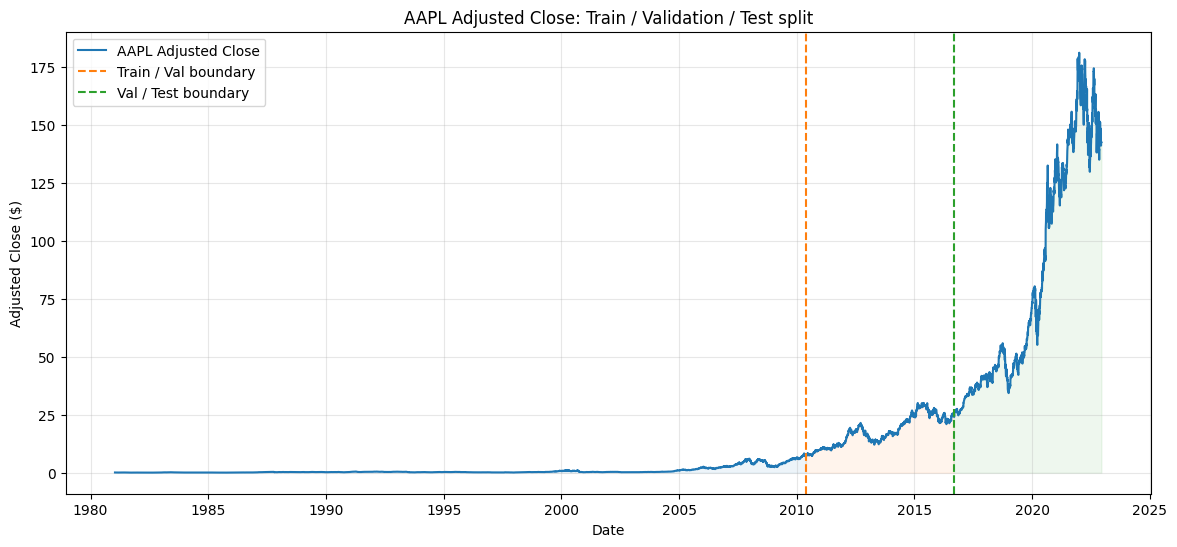

In [34]:
# Plot the AAPL adjusted close trend with chronological split boundaries from the pipeline.
window_size = 30
feat = add_technical_features(AAPL).dropna().reset_index(drop=True)
feat['Date'] = pd.to_datetime(feat['Date'], errors='coerce')
feat = feat.sort_values('Date').reset_index(drop=True)

train_end = AAPL_train.X.shape[0] + window_size - 1
val_end = train_end + AAPL_val.X.shape[0]

plt.figure(figsize=(14, 6))
plt.plot(feat['Date'], feat['Adjusted Close'], label='AAPL Adjusted Close', color='tab:blue')
plt.axvline(feat.loc[train_end, 'Date'], color='tab:orange', linestyle='--', label='Train / Val boundary')
plt.axvline(feat.loc[val_end, 'Date'], color='tab:green', linestyle='--', label='Val / Test boundary')
plt.fill_between(feat['Date'][:train_end+1], feat['Adjusted Close'][:train_end+1], color='tab:blue', alpha=0.08)
plt.fill_between(feat['Date'][train_end+1:val_end+1], feat['Adjusted Close'][train_end+1:val_end+1], color='tab:orange', alpha=0.08)
plt.fill_between(feat['Date'][val_end+1:], feat['Adjusted Close'][val_end+1:], color='tab:green', alpha=0.08)
plt.title('AAPL Adjusted Close: Train / Validation / Test split')
plt.xlabel('Date')
plt.ylabel('Adjusted Close ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
# Sanity checks: shapes, normalisation range, label denormalisation
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Label: {LABEL_COL!r}\n")

for name, tr, va, te in [('AAPL', AAPL_train, AAPL_val, AAPL_test),
                         ('MSFT', MSFT_train, MSFT_val, MSFT_test),
                         ('NVDA', NVDA_train, NVDA_val, NVDA_test)]:
    print(f"[{name}]  X_train {tr.X.shape}  y_train {tr.y.shape}  "
          f"|  X_val {va.X.shape}  |  X_test {te.X.shape}")
    print(f"        X (must be [0, 1]): [{tr.X.min():.3f}, {tr.X.max():.3f}]   "
          f"y (can exceed [0, 1] when day t+1 breaks the window's range): "
          f"[{tr.y.min():.3f}, {tr.y.max():.3f}]")

# Round-trip check: denormalise the first 3 test labels back to dollars
y_recovered = denormalize_label(AAPL_test.y[:3], AAPL_test.label_min[:3], AAPL_test.label_max[:3])
print(f"\nAAPL test labels denormalised → {y_recovered.round(3).tolist()}  (real Adjusted Close prices)")


Features (13): ['Open', 'High', 'Low', 'Close', 'Volume', 'Adjusted Close', 'daily_return', 'MA5', 'MA20', 'RSI', 'MACD', 'MACD_signal', 'volatility']
Label: 'Adjusted Close'

[AAPL]  X_train (7378, 30, 13)  y_train (7378,)  |  X_val (1581, 30, 13)  |  X_test (1581, 30, 13)
        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-1.599, 2.000]
[MSFT]  X_train (6449, 30, 13)  y_train (6449,)  |  X_val (1382, 30, 13)  |  X_test (1383, 30, 13)
        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-2.562, 1.984]
[NVDA]  X_train (4173, 30, 13)  y_train (4173,)  |  X_val (895, 30, 13)  |  X_test (895, 30, 13)
        X (must be [0, 1]): [0.000, 1.000]   y (can exceed [0, 1] when day t+1 breaks the window's range): [-0.812, 2.489]

AAPL test labels denormalised → [24.843000411987305, 25.076000213623047, 25.069000244140625]  (real Adjusted Close prices)


In [36]:
# Train AAPL LSTM (LSTM replaces the sample's Conv1D per the project spec; same MSE/Adam pattern)
# Best epoch (by val_loss) is checkpointed to models/task1.1/AAPL_lstm.keras
AAPL_LSTM_model = Sequential([
    Input(shape=AAPL_train.X.shape[1:]),    # (window_size, n_features) = (30, 13)
    LSTM(64),
    Dense(1),
])
AAPL_LSTM_model.compile(optimizer='adam', loss='mse', metrics=['mse'])

history = train_with_checkpoint(
    AAPL_LSTM_model, AAPL_train, AAPL_val,
    save_path=checkpoint_path('task1.1', 'AAPL_lstm'),
    epochs=10, batch_size=64, verbose=1,
)
# Reload the best-by-val-loss weights so downstream cells use the checkpointed model
AAPL_LSTM_model = load_model(checkpoint_path('task1.1', 'AAPL_lstm'))

Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0490 - mse: 0.0490 - val_loss: 0.0291 - val_mse: 0.0291
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0289 - mse: 0.0289 - val_loss: 0.0258 - val_mse: 0.0258
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0277 - mse: 0.0277 - val_loss: 0.0285 - val_mse: 0.0285
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0278 - mse: 0.0278 - val_loss: 0.0253 - val_mse: 0.0253
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0269 - mse: 0.0269 - val_loss: 0.0255 - val_mse: 0.0255
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0271 - mse: 0.0271 - val_loss: 0.0250 - val_mse: 0.0250
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0273 - mse: 0.0273 - val_loss: 0.0266 - val_mse: 0.0266
Epoch 8/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0268 - mse: 0.0268 - val_loss: 0.0249 - val_mse: 0.0249
Epoch 9/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - 

### Training curves


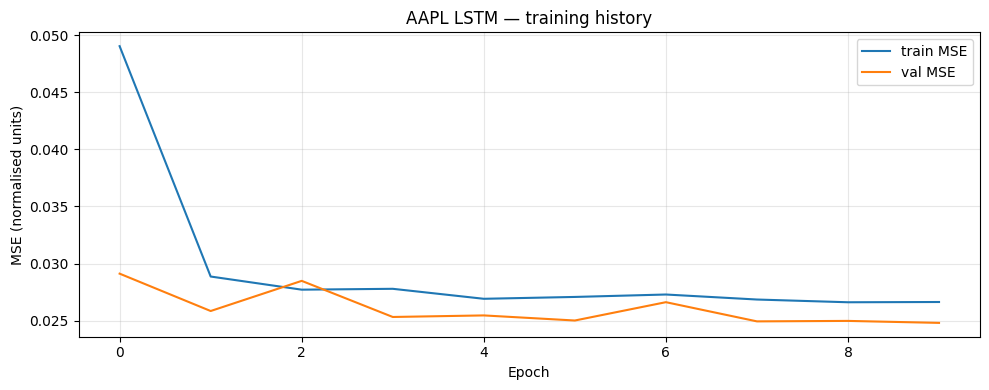

In [37]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='train MSE', color='tab:blue')
plt.plot(history.history['val_loss'], label='val MSE',   color='tab:orange')
plt.title('AAPL LSTM — training history')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalised units)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Test set evaluation — denormalise back to dollar units


In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on test, then invert per-window MinMax → real Adjusted Close in dollars
y_pred_norm = AAPL_LSTM_model.predict(AAPL_test.X, verbose=0).ravel()
y_pred = denormalize_label(y_pred_norm, AAPL_test.label_min, AAPL_test.label_max)
y_real = denormalize_label(AAPL_test.y,  AAPL_test.label_min, AAPL_test.label_max)

mse_norm = mean_squared_error(AAPL_test.y, y_pred_norm)
mse_dol  = mean_squared_error(y_real, y_pred)
rmse_dol = np.sqrt(mse_dol)
mae_dol  = mean_absolute_error(y_real, y_pred)

print(f"AAPL test set  ({len(y_pred)} samples):")
print(f"  MSE  (normalised)  : {mse_norm:.5f}   ← compare with sample's 0.033")
print(f"  MSE  ($²)          : {mse_dol:.4f}")
print(f"  RMSE ($)           : {rmse_dol:.4f}")
print(f"  MAE  ($)           : {mae_dol:.4f}")


AAPL test set  (1581 samples):
  MSE  (normalised)  : 0.02457   ← compare with sample's 0.033
  MSE  ($²)          : 4.0220
  RMSE ($)           : 2.0055
  MAE  ($)           : 1.2329


### Predicted vs real Adjusted Close (AAPL test set)


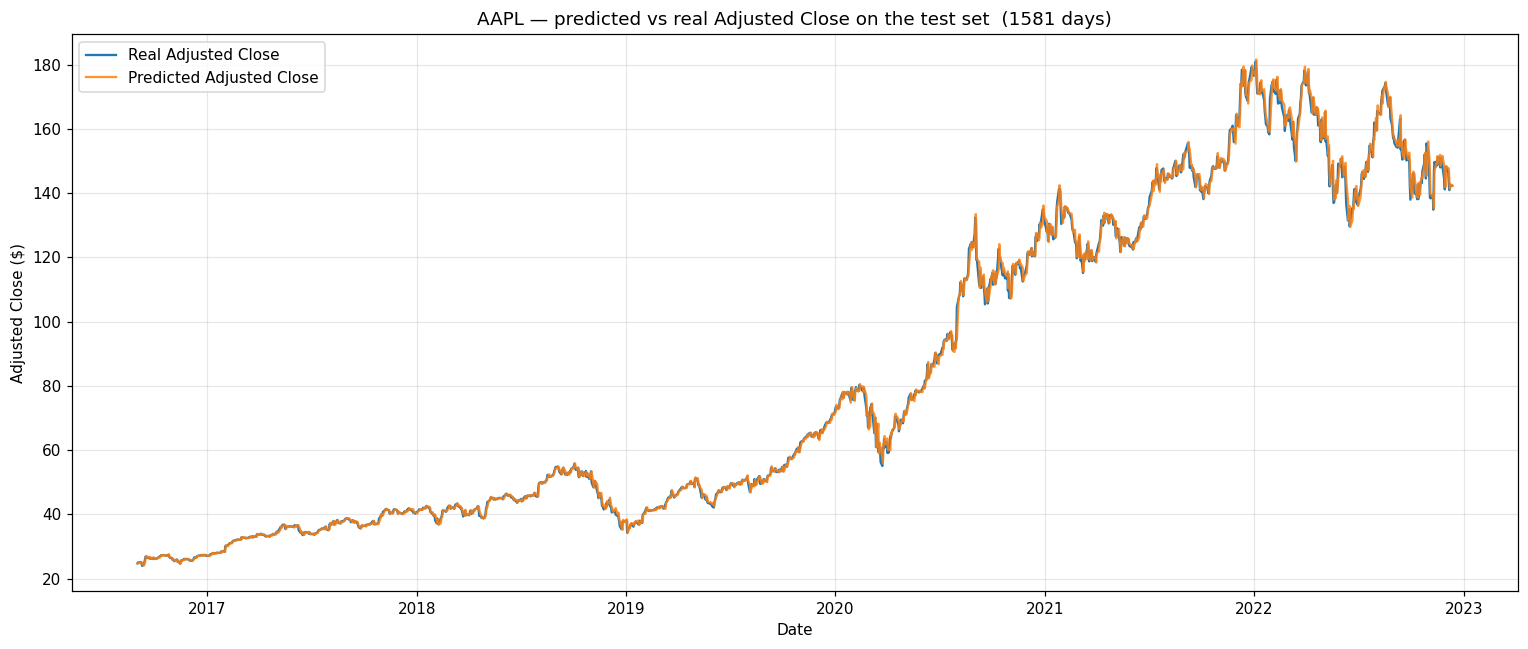

In [39]:
# Recover the calendar date for each test label so x-axis is real time, not row index
window_size, horizon = 30, 1
feat_aapl = add_technical_features(AAPL).dropna().reset_index(drop=True)
test_start_idx = AAPL_train.X.shape[0] + AAPL_val.X.shape[0]
test_label_dates = feat_aapl['Date'].iloc[
    test_start_idx + window_size + horizon - 1 :
    test_start_idx + window_size + horizon - 1 + len(y_pred)
].reset_index(drop=True)

plt.figure(figsize=(14, 6), dpi=110)
plt.plot(test_label_dates, y_real, label='Real Adjusted Close',     color='tab:blue')
plt.plot(test_label_dates, y_pred, label='Predicted Adjusted Close', color='tab:orange', alpha=0.85)
plt.title(f'AAPL — predicted vs real Adjusted Close on the test set  ({len(y_pred)} days)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 1.1 extension — apply the same pipeline to MSFT and NVDA

The pipeline is ticker-agnostic. We reuse the splits already built by `build_pipeline` (`MSFT_train/_val/_test`, `NVDA_train/_val/_test`) and train an LSTM with **identical architecture and hyperparameters** as the AAPL baseline. Each model's best epoch (by `val_loss`) is checkpointed to `models/task1.1/<TICKER>_lstm.keras` and reloaded so downstream evaluation uses the best weights.

`evaluate_test` is defined here (rather than later in 1.2) because we need it to score all three tickers in one comparison table — 1.2 will then reuse it as-is.

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


def build_lstm(input_shape):
    """LSTM(64) → Dense(1), Adam + MSE — the architecture used everywhere in Task 1."""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64),
        Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    return model


def evaluate_test(model, test):
    """Predict on the test split, denormalise, and return (y_real, y_pred, metrics-dict)."""
    y_pred_norm = model.predict(test.X, verbose=0).ravel()
    y_pred = denormalize_label(y_pred_norm, test.label_min, test.label_max)
    y_real = denormalize_label(test.y,      test.label_min, test.label_max)
    mse_norm = mean_squared_error(test.y, y_pred_norm)
    mse_dol  = mean_squared_error(y_real, y_pred)
    return y_real, y_pred, {
        'MSE (norm)': mse_norm,
        'MSE ($²)':   mse_dol,
        'RMSE ($)':   np.sqrt(mse_dol),
        'MAE ($)':    mean_absolute_error(y_real, y_pred),
    }


TICKERS = ['AAPL', 'MSFT', 'NVDA']
SPLITS_K1 = {
    'AAPL': (AAPL_train, AAPL_val, AAPL_test),
    'MSFT': (MSFT_train, MSFT_val, MSFT_test),
    'NVDA': (NVDA_train, NVDA_val, NVDA_test),
}

# results_k1[ticker] = {'model','history','train','val','test'}
results_k1 = {
    'AAPL': {'model': AAPL_LSTM_model, 'history': history,
             'train': AAPL_train, 'val': AAPL_val, 'test': AAPL_test},
}

for ticker in ['MSFT', 'NVDA']:
    tr, va, te = SPLITS_K1[ticker]
    print(f"\n=== Training {ticker} LSTM (k=1) ===")
    model = build_lstm(tr.X.shape[1:])
    hist  = train_with_checkpoint(
        model, tr, va,
        save_path=checkpoint_path('task1.1', f'{ticker}_lstm'),
        epochs=10, batch_size=64, verbose=1,
    )
    # Reload best-by-val-loss checkpoint
    model = load_model(checkpoint_path('task1.1', f'{ticker}_lstm'))
    results_k1[ticker] = {'model': model, 'history': hist,
                          'train': tr, 'val': va, 'test': te}

# Expose MSFT/NVDA models under conventional names too, for symmetry with AAPL_LSTM_model
MSFT_LSTM_model = results_k1['MSFT']['model']
NVDA_LSTM_model = results_k1['NVDA']['model']


=== Training MSFT LSTM (k=1) ===
Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0570 - mse: 0.0570 - val_loss: 0.0424 - val_mse: 0.0424
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0322 - mse: 0.0322 - val_loss: 0.0345 - val_mse: 0.0345
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0287 - mse: 0.0287 - val_loss: 0.0334 - val_mse: 0.0334
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0283 - mse: 0.0283 - val_loss: 0.0347 - val_mse: 0.0347
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0281 - mse: 0.0281 - val_loss: 0.0353 - val_mse: 0.0353
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0282 - mse: 0.0282 - val_loss: 0.0332 - val_mse: 0.0332
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0282 - mse: 0.0282 - val_loss: 0.0341 - val_mse: 0.0341
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0277 - mse: 0.0277 - val_loss: 0.0332 - val_mse: 0.0332
Epoch 9/10
101/101 ━━

#### Cross-ticker comparison (k = 1)

Per-ticker dollar metrics are not directly comparable (NVDA spans a tighter dollar range than AAPL), but the **normalised MSE** is — it's already on the per-window-MinMax scale.

In [41]:
print(f"Task 1.1 — k=1 forecast, all tickers\n")
print(f"{'ticker':>6}  {'MSE (norm)':>11}  {'MSE ($²)':>10}  {'RMSE ($)':>10}  {'MAE ($)':>10}")
print('-' * 55)
for ticker in TICKERS:
    r = results_k1[ticker]
    _, _, m = evaluate_test(r['model'], r['test'])
    print(f"{ticker:>6}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>10.4f}  "
          f"{m['RMSE ($)']:>10.4f}  {m['MAE ($)']:>10.4f}")

Task 1.1 — k=1 forecast, all tickers

ticker   MSE (norm)    MSE ($²)    RMSE ($)     MAE ($)
-------------------------------------------------------
  AAPL      0.02457      4.0220      2.0055      1.2329
  MSFT      0.02900     13.7469      3.7077      2.4313
  NVDA      0.02619     33.6673      5.8024      3.8298


# 1.2 kᵗʰ day forecast

Task 1.1 predicts the **next** day (`horizon = 1`). Task 1.2 instead predicts the price on the **kᵗʰ day after the input window** — e.g., the 3rd or 7th day ahead.

The `build_pipeline(..., horizon=k)` helper from 1.1 already supports this: each label is `label[i + window_size + k - 1]`, i.e., the kᵗʰ day after the window ends. So 1.2 reuses the same pipeline, model, and training loop — only `horizon` changes.

We train an LSTM at **k ∈ {3, 7}** for all three tickers (AAPL, MSFT, NVDA), identical architecture and hyperparameters as 1.1, and compare against the k = 1 baseline. Best epochs are checkpointed to `models/task1.2/<TICKER>_k<k>.keras`. As expected, forecast error grows with k — the further ahead we predict, the less the recent 30-day window carries information about the target day.

In [42]:
# Build pipelines and train LSTMs for each (ticker, k) — same architecture & hyperparameters as 1.1
# build_lstm was defined in 1.1's extension cell.
K_VALUES = [3, 7]
RAW_FRAMES = {'AAPL': AAPL, 'MSFT': MSFT, 'NVDA': NVDA}

# results_kth[(ticker, k)] = dict(model, history, train, val, test)
results_kth = {}

for ticker in TICKERS:
    for k in K_VALUES:
        print(f"\n=== Training {ticker} LSTM (k={k}) ===")
        tr, va, te = build_pipeline(RAW_FRAMES[ticker], f'{ticker} k={k}', horizon=k)
        model = build_lstm(tr.X.shape[1:])
        hist  = train_with_checkpoint(
            model, tr, va,
            save_path=checkpoint_path('task1.2', f'{ticker}_k{k}'),
            epochs=10, batch_size=64, verbose=0,
        )
        model = load_model(checkpoint_path('task1.2', f'{ticker}_k{k}'))
        results_kth[(ticker, k)] = {'model': model, 'history': hist,
                                    'train': tr, 'val': va, 'test': te}
        print(f"  → final val_loss = {hist.history['val_loss'][-1]:.5f}  "
              f"(best = {min(hist.history['val_loss']):.5f})")


=== Training AAPL LSTM (k=3) ===
[AAPL k=3 ]  X_train: (7376, 30, 13)  X_val: (1581, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=3, n_features=13)
  ↳ best checkpoint → models/task1.2/AAPL_k3.keras
  → final val_loss = 0.07877  (best = 0.07877)

=== Training AAPL LSTM (k=7) ===
[AAPL k=7 ]  X_train: (7373, 30, 13)  X_val: (1580, 30, 13)  X_test: (1581, 30, 13)  (window=30, horizon=7, n_features=13)
  ↳ best checkpoint → models/task1.2/AAPL_k7.keras
  → final val_loss = 0.19046  (best = 0.18786)

=== Training MSFT LSTM (k=3) ===
[MSFT k=3 ]  X_train: (6448, 30, 13)  X_val: (1382, 30, 13)  X_test: (1382, 30, 13)  (window=30, horizon=3, n_features=13)
  ↳ best checkpoint → models/task1.2/MSFT_k3.keras
  → final val_loss = 0.11065  (best = 0.10734)

=== Training MSFT LSTM (k=7) ===
[MSFT k=7 ]  X_train: (6444, 30, 13)  X_val: (1382, 30, 13)  X_test: (1382, 30, 13)  (window=30, horizon=7, n_features=13)
  ↳ best checkpoint → models/task1.2/MSFT_k7.keras
  → final val_loss = 0.2457

### Test-set comparison: k ∈ {1, 3, 7} across all three tickers

All metrics are computed on the **denormalised** test predictions (real Adjusted Close dollars). Normalised MSE is on the per-window MinMax scale and is the most directly comparable across tickers; the dollar metrics aren't (NVDA's prices live in a different range than AAPL's).

In [43]:
# Build a single table covering all (ticker, k) combinations.
# evaluate_test was defined in the 1.1 extension cell.

print(f"Task 1.2 — kᵗʰ-day forecast, all tickers × k ∈ {{1, 3, 7}}\n")
print(f"{'ticker':>6}  {'k':>3}  {'MSE (norm)':>11}  {'MSE ($²)':>10}  {'RMSE ($)':>10}  {'MAE ($)':>10}")
print('-' * 62)

for ticker in TICKERS:
    # k = 1 baseline (from 1.1)
    r1 = results_k1[ticker]
    _, _, m = evaluate_test(r1['model'], r1['test'])
    print(f"{ticker:>6}  {1:>3}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>10.4f}  "
          f"{m['RMSE ($)']:>10.4f}  {m['MAE ($)']:>10.4f}")
    # k ∈ {3, 7} from 1.2
    for k in K_VALUES:
        r = results_kth[(ticker, k)]
        _, _, m = evaluate_test(r['model'], r['test'])
        print(f"{ticker:>6}  {k:>3}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>10.4f}  "
              f"{m['RMSE ($)']:>10.4f}  {m['MAE ($)']:>10.4f}")
    print('-' * 62)

Task 1.2 — kᵗʰ-day forecast, all tickers × k ∈ {1, 3, 7}

ticker    k   MSE (norm)    MSE ($²)    RMSE ($)     MAE ($)
--------------------------------------------------------------
  AAPL    1      0.02457      4.0220      2.0055      1.2329
  AAPL    3      0.07641     11.2892      3.3599      2.1114
  AAPL    7      0.18307     24.1643      4.9157      3.2361
--------------------------------------------------------------
  MSFT    1      0.02900     13.7469      3.7077      2.4313
  MSFT    3      0.07581     34.9734      5.9138      3.9359
  MSFT    7      0.17408     85.4983      9.2465      6.2349
--------------------------------------------------------------
  NVDA    1      0.02619     33.6673      5.8024      3.8298
  NVDA    3      0.07203     90.0533      9.4896      6.3835
  NVDA    7      0.17489    210.9241     14.5232      9.7407
--------------------------------------------------------------


### Predicted vs real — AAPL at k = 3 and k = 7

Visualised for AAPL only — the table above covers MSFT and NVDA in numbers, and a second visual demonstrates the same error-grows-with-k behaviour. The label for the iᵗʰ test window lands at original index `i + N_train + N_val + window_size + k − 1` in the feature-engineered series.

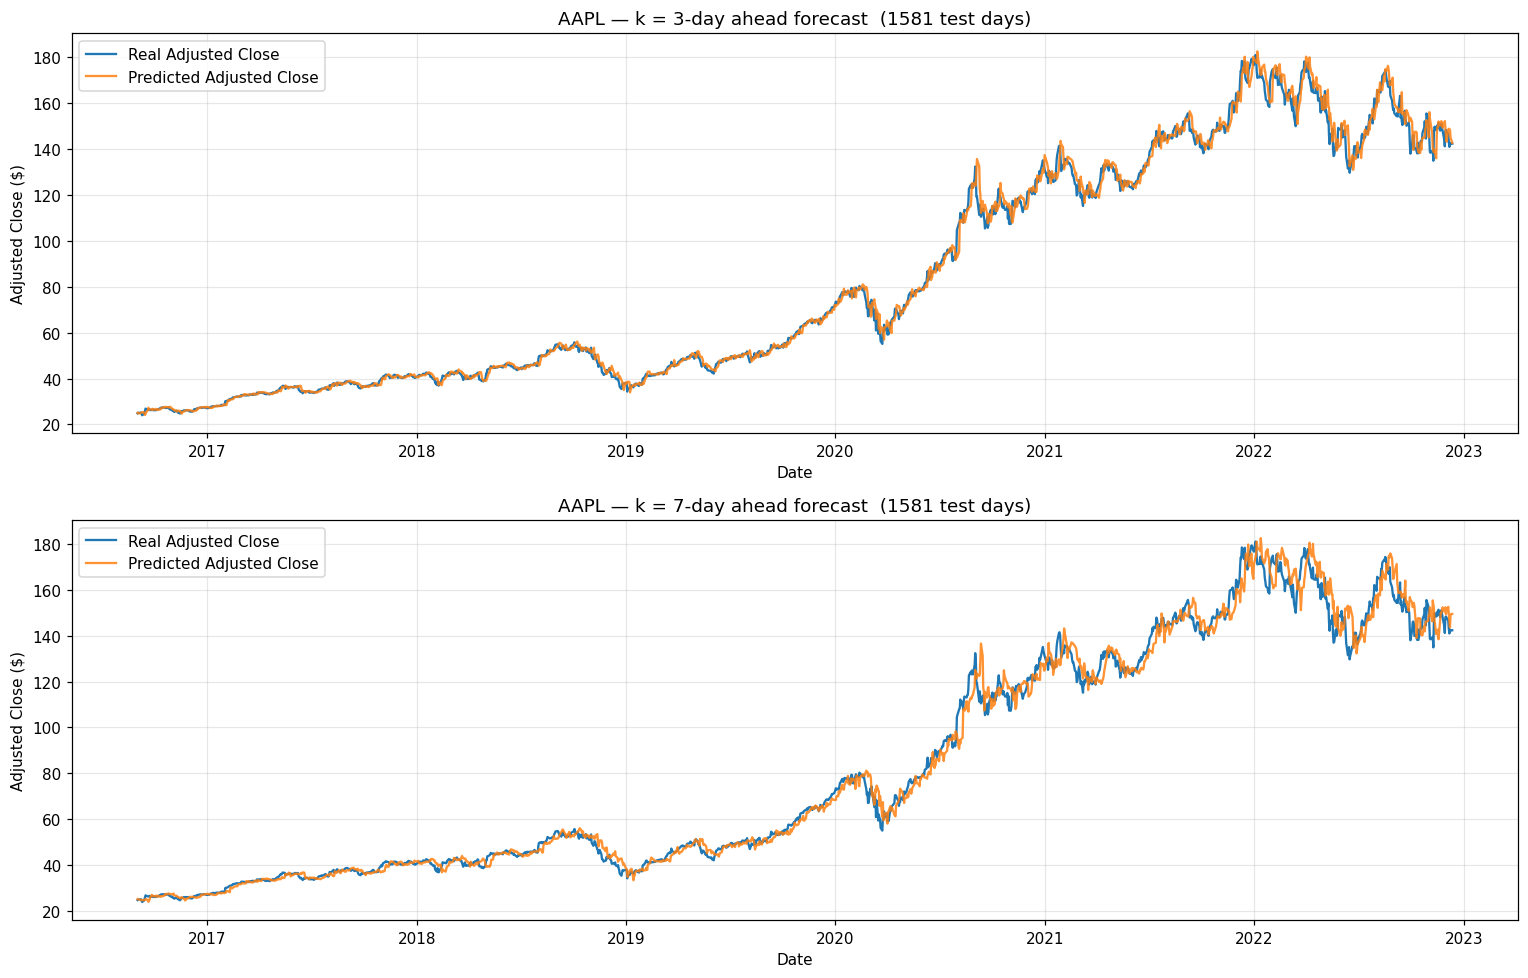

In [44]:
window_size = 30
fig, axes = plt.subplots(2, 1, figsize=(14, 9), dpi=110)

for ax, k in zip(axes, K_VALUES):
    r = results_kth[('AAPL', k)]
    y_real, y_pred, _ = evaluate_test(r['model'], r['test'])

    test_start_idx = r['train'].X.shape[0] + r['val'].X.shape[0]
    label_offset   = window_size + k - 1
    dates = feat_aapl['Date'].iloc[
        test_start_idx + label_offset :
        test_start_idx + label_offset + len(y_pred)
    ].reset_index(drop=True)

    ax.plot(dates, y_real, label='Real Adjusted Close',      color='tab:blue')
    ax.plot(dates, y_pred, label='Predicted Adjusted Close', color='tab:orange', alpha=0.85)
    ax.set_title(f'AAPL — k = {k}-day ahead forecast  ({len(y_pred)} test days)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Adjusted Close ($)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 1.3 k consecutive days forecast

Tasks 1.1–1.2 predict a **single** future day (next day, or the kᵗʰ day). Task 1.3 instead predicts the **entire sequence** of the next k days at once: for k = 3 the model outputs `[day+1, day+2, day+3]`; for k = 7 it outputs `[day+1, …, day+7]`.

The only structural changes vs 1.2:

- **Label** is now a length-k vector per window — `y[i] = label[i+window_size : i+window_size+k]`.
- **Model head** is `Dense(k)` instead of `Dense(1)`. Same LSTM(64) trunk, same Adam + MSE, same per-window MinMax (the input window's Adj Close min/max scales all k label components uniformly so denormalisation stays one-pair-per-window).
- **Metrics** are reported per step (`step=1` ≈ shortest horizon, `step=k` ≈ longest) so we can read the error-growth curve directly.

Checkpoints land under `models/task1.3/<TICKER>_k<k>.keras`. The window count per (ticker, k) matches 1.2 exactly, since both pipelines need k future days after the input window.

In [45]:
# Multi-step pipeline: same per-window MinMax as 1.1/1.2, but labels are k consecutive future values of the label column.


class MultiStepSplit(NamedTuple):
    X:         np.ndarray  # (N, window_size, n_features)
    y:         np.ndarray  # (N, k)                       — normalised
    label_min: np.ndarray  # (N,)  per-window label-column min
    label_max: np.ndarray  # (N,)  per-window label-column max


def build_pipeline_multistep(df, name, k, window_size=30,
                             val_ratio=0.15, test_ratio=0.15, verbose=True,
                             feature_cols=None, label_col=None):
    """Same pipeline as `build_pipeline`, but each label is the next k values
    of the label column. `feature_cols`/`label_col` default to the Nasdaq
    globals; Task 2 passes Vietnam-specific lists.
    """
    feat_cols = feature_cols if feature_cols is not None else FEATURE_COLS
    lbl_col   = label_col    if label_col    is not None else LABEL_COL
    feat = add_technical_features(df).dropna().reset_index(drop=True)
    label_idx = feat_cols.index(lbl_col)

    arr   = feat[feat_cols].values.astype(np.float32)
    label = feat[lbl_col].values.astype(np.float32)

    X_list, y_list = [], []
    for i in range(len(arr) - window_size - k + 1):
        X_list.append(arr[i : i + window_size])
        y_list.append(label[i + window_size : i + window_size + k])
    X = np.stack(X_list)
    y = np.stack(y_list).astype(np.float32)               # (N, k)

    X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
    val_size_adj = val_ratio / (1 - test_ratio)
    X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=val_size_adj, shuffle=False)

    def normalise(Xs, ys):
        fmins = Xs.min(axis=1, keepdims=True)             # (N, 1, F)
        fmaxs = Xs.max(axis=1, keepdims=True)
        Xn    = (Xs - fmins) / (fmaxs - fmins + 1e-8)
        lmin  = fmins[:, 0, label_idx]                    # (N,)
        lmax  = fmaxs[:, 0, label_idx]
        # broadcast the input-window's stats across all k label steps
        yn    = (ys - lmin[:, None]) / (lmax - lmin + 1e-8)[:, None]
        return MultiStepSplit(Xn.astype(np.float32), yn.astype(np.float32), lmin, lmax)

    train, val, test = normalise(X_train, y_train), normalise(X_val, y_val), normalise(X_test, y_test)

    if verbose:
        print(f"[{name:9s}]  X_train: {train.X.shape}  y_train: {train.y.shape}  "
              f"X_test: {test.X.shape}  (window={window_size}, k={k})")
    return train, val, test


def build_lstm_multistep(input_shape, k):
    """LSTM(64) → Dense(k) — same trunk as build_lstm, vector head for k-day forecast."""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64),
        Dense(k),
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    return model


def denormalize_label_multistep(y_norm, label_min, label_max):
    """Invert per-window MinMax for (N, k) predictions."""
    return y_norm * (label_max - label_min + 1e-8)[:, None] + label_min[:, None]


def evaluate_test_multistep(model, test):
    """Predict → denormalise → return (y_real (N,k), y_pred (N,k), metrics-dict).

    metrics-dict contains the overall (all-steps-pooled) MSE/RMSE/MAE plus per-step RMSE/MAE.
    """
    y_pred_norm = model.predict(test.X, verbose=0)                       # (N, k)
    y_pred = denormalize_label_multistep(y_pred_norm, test.label_min, test.label_max)
    y_real = denormalize_label_multistep(test.y,      test.label_min, test.label_max)

    mse_norm = mean_squared_error(test.y.ravel(), y_pred_norm.ravel())
    mse_dol  = mean_squared_error(y_real.ravel(), y_pred.ravel())
    per_step_rmse = np.sqrt(((y_real - y_pred) ** 2).mean(axis=0))       # (k,)
    per_step_mae  = np.abs(y_real - y_pred).mean(axis=0)                 # (k,)
    return y_real, y_pred, {
        'MSE (norm)':    mse_norm,
        'MSE ($²)':      mse_dol,
        'RMSE ($)':      np.sqrt(mse_dol),
        'MAE ($)':       mean_absolute_error(y_real.ravel(), y_pred.ravel()),
        'RMSE per step': per_step_rmse,
        'MAE per step':  per_step_mae,
    }

In [46]:
# Train multi-step LSTMs for each (ticker, k). Same hyperparameters as 1.2; only the head changes.
# results_kday[(ticker, k)] = {'model','history','train','val','test'}
results_kday = {}

for ticker in TICKERS:
    for k in K_VALUES:
        print(f"\n=== Training {ticker} multi-step LSTM (k={k}) ===")
        tr, va, te = build_pipeline_multistep(RAW_FRAMES[ticker], f'{ticker} k={k}', k=k)
        model = build_lstm_multistep(tr.X.shape[1:], k=k)
        hist  = train_with_checkpoint(
            model, tr, va,
            save_path=checkpoint_path('task1.3', f'{ticker}_k{k}'),
            epochs=10, batch_size=64, verbose=0,
        )
        model = load_model(checkpoint_path('task1.3', f'{ticker}_k{k}'))
        results_kday[(ticker, k)] = {'model': model, 'history': hist,
                                     'train': tr, 'val': va, 'test': te}
        print(f"  → final val_loss = {hist.history['val_loss'][-1]:.5f}  "
              f"(best = {min(hist.history['val_loss']):.5f})")



=== Training AAPL multi-step LSTM (k=3) ===
[AAPL k=3 ]  X_train: (7376, 30, 13)  y_train: (7376, 3)  X_test: (1581, 30, 13)  (window=30, k=3)
  ↳ best checkpoint → models/task1.3/AAPL_k3.keras
  → final val_loss = 0.05200  (best = 0.05200)

=== Training AAPL multi-step LSTM (k=7) ===
[AAPL k=7 ]  X_train: (7373, 30, 13)  y_train: (7373, 7)  X_test: (1581, 30, 13)  (window=30, k=7)
  ↳ best checkpoint → models/task1.3/AAPL_k7.keras
  → final val_loss = 0.10832  (best = 0.10698)

=== Training MSFT multi-step LSTM (k=3) ===
[MSFT k=3 ]  X_train: (6448, 30, 13)  y_train: (6448, 3)  X_test: (1382, 30, 13)  (window=30, k=3)
  ↳ best checkpoint → models/task1.3/MSFT_k3.keras
  → final val_loss = 0.07126  (best = 0.07072)

=== Training MSFT multi-step LSTM (k=7) ===
[MSFT k=7 ]  X_train: (6444, 30, 13)  y_train: (6444, 7)  X_test: (1382, 30, 13)  (window=30, k=7)
  ↳ best checkpoint → models/task1.3/MSFT_k7.keras
  → final val_loss = 0.13927  (best = 0.13624)

=== Training NVDA multi-step LS

### Per-step error growth — all tickers × k ∈ {3, 7}

For each (ticker, k) we report the **per-step** RMSE/MAE in dollars (step 1 = next day, step k = furthest horizon) plus an aggregate over all steps. The relevant *new* axis vs 1.2 is the **step index** — it lets us see whether error grows linearly, plateaus, or explodes as we look further out. The aggregate `MSE (norm)` row is comparable across tickers (per-window MinMax scale); the dollar rows aren't, for the same reason as in 1.2.

In [47]:
# Per-step + aggregate metrics for every (ticker, k) trained in 1.3.
print(f"Task 1.3 — k consecutive days forecast, all tickers × k ∈ {K_VALUES}\n")

for ticker in TICKERS:
    for k in K_VALUES:
        r = results_kday[(ticker, k)]
        _, _, m = evaluate_test_multistep(r['model'], r['test'])
        print(f"[{ticker}  k={k}]  "
              f"MSE(norm)={m['MSE (norm)']:.5f}  "
              f"RMSE(${'$'})={m['RMSE ($)']:.4f}  "
              f"MAE(${'$'})={m['MAE ($)']:.4f}")
        print(f"{'':>11}  step:  " + "  ".join(f"{s:>7d}" for s in range(1, k + 1)))
        print(f"{'':>11}  RMSE:  " + "  ".join(f"{v:7.3f}" for v in m['RMSE per step']))
        print(f"{'':>11}  MAE :  " + "  ".join(f"{v:7.3f}" for v in m['MAE per step']))
        print()


Task 1.3 — k consecutive days forecast, all tickers × k ∈ [3, 7]

[AAPL  k=3]  MSE(norm)=0.05159  RMSE($$)=2.7421  MAE($$)=1.7039
             step:        1        2        3
             RMSE:    2.026    2.741    3.307
             MAE :    1.250    1.746    2.116

[AAPL  k=7]  MSE(norm)=0.10261  RMSE($$)=3.7406  MAE($$)=2.3318
             step:        1        2        3        4        5        6        7
             RMSE:    2.014    2.753    3.262    3.767    4.111    4.539    4.896
             MAE :    1.256    1.741    2.077    2.421    2.653    2.961    3.213

[MSFT  k=3]  MSE(norm)=0.05339  RMSE($$)=4.9395  MAE($$)=3.2237
             step:        1        2        3
             RMSE:    3.723    4.929    5.920
             MAE :    2.456    3.278    3.937

[MSFT  k=7]  MSE(norm)=0.09899  RMSE($$)=6.8791  MAE($$)=4.4785
             step:        1        2        3        4        5        6        7
             RMSE:    3.766    4.908    6.016    6.776    7.529    8.65

### AAPL — example 7-day forecast trajectories

Plotting AAPL only — the cross-ticker comparison is fully captured by the table above. The *new* axis 1.3 introduces is the **forecast trajectory** itself (a vector of k predictions from one starting date), which neither 1.1's nor 1.2's plots can show — those plot a single horizon over many dates.

Six evenly-spaced starting dates from the AAPL test set, k = 7. Each panel overlays the model's predicted 7-day path against the realised one starting from the same date.

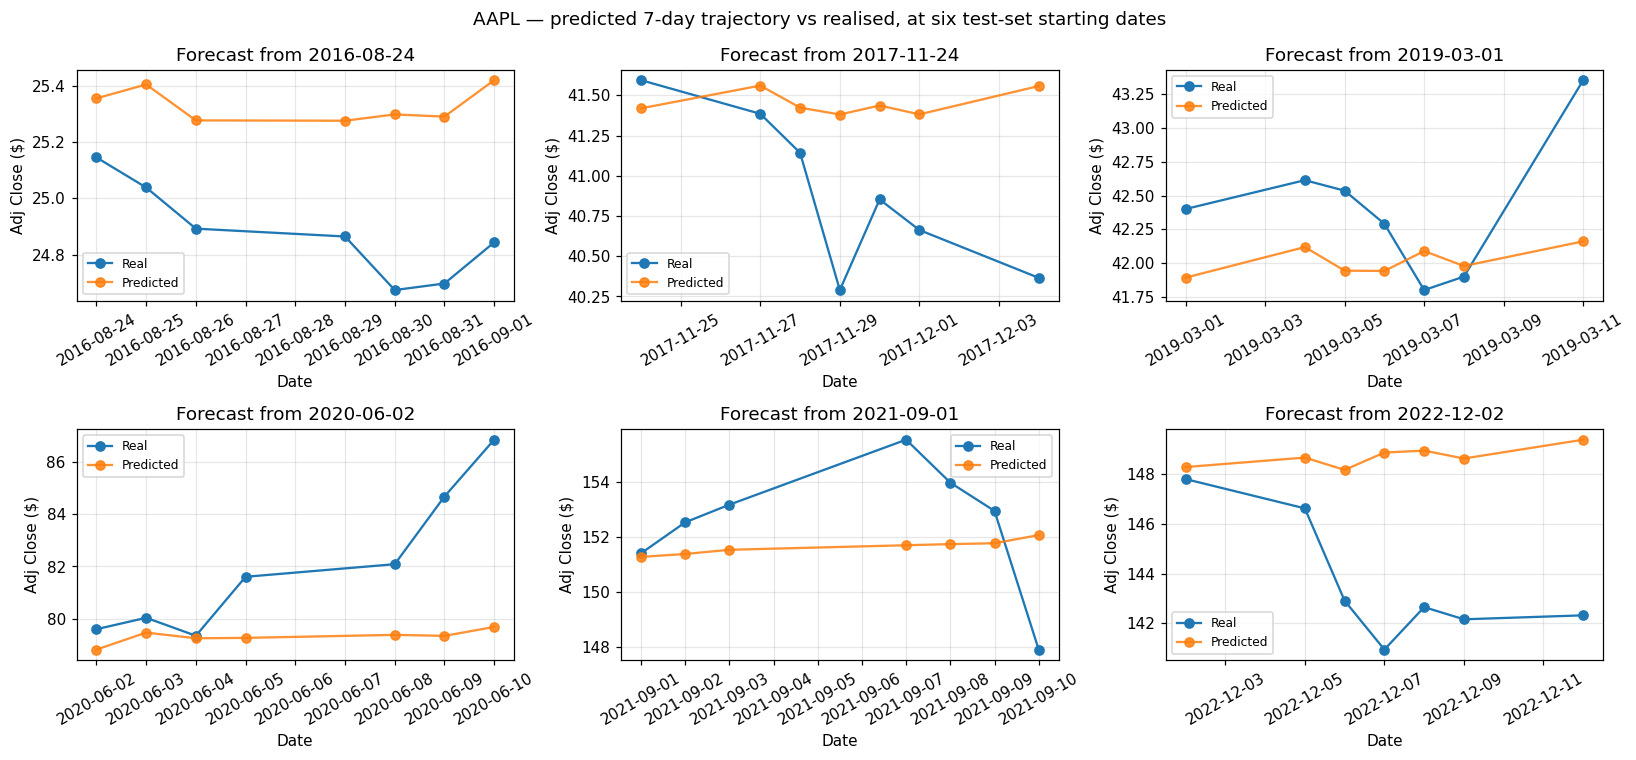

In [48]:
# AAPL k=7 forecast trajectories at six evenly-spaced starting dates from the test set.
window_size = 30
k = 7
r = results_kday[('AAPL', k)]
y_real, y_pred, _ = evaluate_test_multistep(r['model'], r['test'])     # (N, 7) each

# Recover the calendar date of the *first* predicted day for each test window.
test_start_idx = r['train'].X.shape[0] + r['val'].X.shape[0]
first_label_offset = window_size
N = y_pred.shape[0]
sample_indices = np.linspace(0, N - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), dpi=110, sharey=False)
for ax, idx in zip(axes.ravel(), sample_indices):
    base_idx = test_start_idx + first_label_offset + idx
    dates = feat_aapl['Date'].iloc[base_idx : base_idx + k].reset_index(drop=True)

    ax.plot(dates, y_real[idx], marker='o', label='Real',      color='tab:blue')
    ax.plot(dates, y_pred[idx], marker='o', label='Predicted', color='tab:orange', alpha=0.85)
    ax.set_title(f"Forecast from {dates.iloc[0].date()}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Adj Close ($)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('AAPL — predicted 7-day trajectory vs realised, at six test-set starting dates')
plt.tight_layout()
plt.show()


# TASK 2 — Vietnam stock price prediction


# 2.1 Vietnam multi-feature next-day forecast

Mirrors Task 1.1 on the Vietnam dataset. Six large-cap HOSE tickers, chosen to span banking, industrials, technology, consumer staples, and retail — the sectors with the deepest historical data:

| Ticker | Sector | CSV |
|---|---|---|
| VCB | Banking | `VCB-VNINDEX-History.csv` |
| HPG | Steel / industrials | `HPG-VNINDEX-History.csv` |
| FPT | Technology | `FPT-VNINDEX-History.csv` |
| VNM | Consumer staples (dairy) | `VNM-VNINDEX-History.csv` |
| MSN | Consumer / retail conglomerate | `MSN-VNINDEX-History.csv` |
| MWG | Tech retail | `MWG-VNINDEX-History.csv` |

**Pipeline differences vs Task 1**:

- **No `Adjusted Close` column** in the Vietnam CSVs → label is `Close`. Feature tensor is 12-wide instead of 13 (OHLCV + the same 7 engineered indicators, no Adj Close).
- **Date column** is `TradingDate` in `YYYY-MM-DD` format and there's a leading unnamed index column. `load_vietnam` normalises both before features are computed.
- **Everything else is identical** — same 30-day window, 70/15/15 chronological split, per-window MinMax, `LSTM(64) → Dense(1)`, Adam + MSE, 10 epochs, batch 64, checkpoint best-by-val-loss. We thread the Vietnam feature/label column lists through the same `build_pipeline` / `build_pipeline_multistep` helpers (added optional `feature_cols=` / `label_col=` kwargs); Task 1 cells are unchanged.

We plot the predicted-vs-real curve for **VCB only** (the longest-history blue chip in the set, representative of the dataset). Per-ticker plots for the other 5 don't add information beyond the comparison tables.


In [49]:
# Load the 6 Vietnam tickers and define the Vietnam-side feature/label columns.
VN_TICKERS = ['VCB', 'HPG', 'FPT', 'VNM', 'MSN', 'MWG']
VN_DATA_DIR = Path('Vietnam data/stock-historical-data')

VN_FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume',
                   'daily_return', 'MA5', 'MA20', 'RSI',
                   'MACD', 'MACD_signal', 'volatility']    # 12 features (no Adjusted Close)
VN_LABEL_COL = 'Close'


def load_vietnam(ticker):
    """Read <ticker>-VNINDEX-History.csv → DataFrame with parsed Date / OHLCV columns."""
    df = pd.read_csv(VN_DATA_DIR / f'{ticker}-VNINDEX-History.csv')
    df = df.drop(columns=df.columns[0])                    # drop the leading unnamed index column
    df = df.rename(columns={'TradingDate': 'Date'})
    df['Date'] = pd.to_datetime(df['Date'])                # YYYY-MM-DD parses automatically
    return df.sort_values('Date').reset_index(drop=True)


VN_RAW_FRAMES = {t: load_vietnam(t) for t in VN_TICKERS}
for t in VN_TICKERS:
    df = VN_RAW_FRAMES[t]
    print(f"  [{t:>3}] {len(df):>5} rows   {df['Date'].min().date()} → {df['Date'].max().date()}")


  [VCB]  3413 rows   2009-06-30 → 2023-02-28
  [HPG]  3809 rows   2007-11-15 → 2023-02-28
  [FPT]  4038 rows   2006-12-13 → 2023-02-28
  [VNM]  4264 rows   2006-01-19 → 2023-02-28
  [MSN]  3322 rows   2009-11-05 → 2023-02-28
  [MWG]  2157 rows   2014-07-14 → 2023-02-28


In [50]:
# Run the same `build_pipeline` (now parameterised) for every Vietnam ticker — horizon = 1.
VN_SPLITS_K1 = {
    t: build_pipeline(
        VN_RAW_FRAMES[t], t, horizon=1,
        feature_cols=VN_FEATURE_COLS, label_col=VN_LABEL_COL,
    )
    for t in VN_TICKERS
}


[VCB      ]  X_train: (2353, 30, 12)  X_val: (505, 30, 12)  X_test: (505, 30, 12)  (window=30, horizon=1, n_features=12)
[HPG      ]  X_train: (2631, 30, 12)  X_val: (564, 30, 12)  X_test: (564, 30, 12)  (window=30, horizon=1, n_features=12)
[FPT      ]  X_train: (2790, 30, 12)  X_val: (599, 30, 12)  X_test: (599, 30, 12)  (window=30, horizon=1, n_features=12)
[VNM      ]  X_train: (2949, 30, 12)  X_val: (632, 30, 12)  X_test: (633, 30, 12)  (window=30, horizon=1, n_features=12)
[MSN      ]  X_train: (2290, 30, 12)  X_val: (491, 30, 12)  X_test: (491, 30, 12)  (window=30, horizon=1, n_features=12)
[MWG      ]  X_train: (1474, 30, 12)  X_val: (316, 30, 12)  X_test: (317, 30, 12)  (window=30, horizon=1, n_features=12)


### VCB train / validation / test split visualisation

Same chronological 70 / 15 / 15 split as Task 1, plotted for VCB as the representative ticker — the longest-running large-cap bank in the set, so the orange/green split boundaries land in distinct market regimes (the 2022 correction is in the test set).


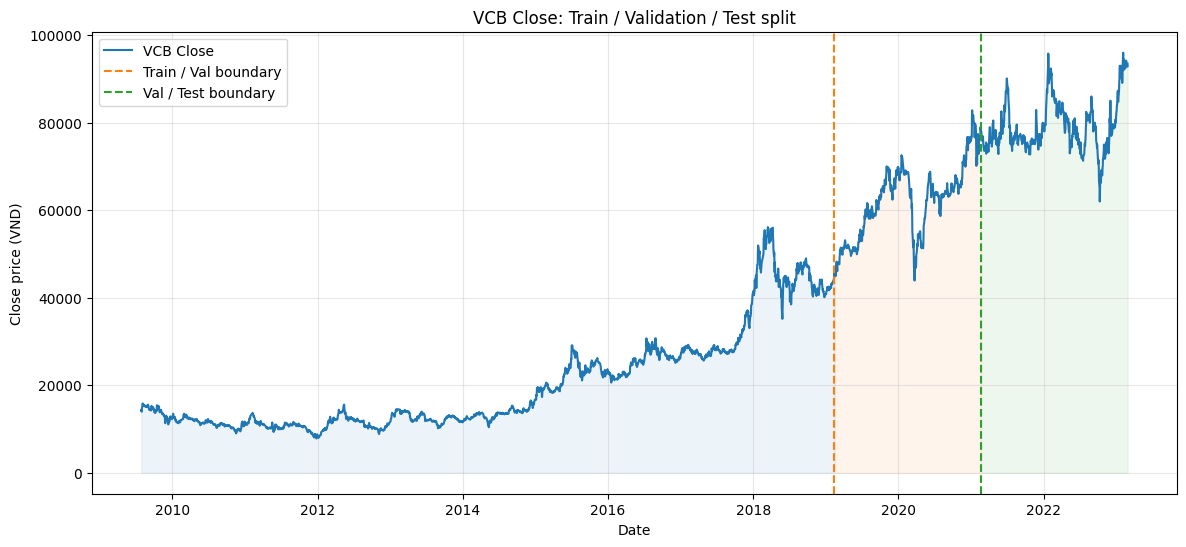

In [51]:
# VCB split-boundary plot — same construction as the AAPL plot in Task 1.1.
window_size = 30
feat_vcb = add_technical_features(VN_RAW_FRAMES['VCB']).dropna().reset_index(drop=True)
vcb_train, vcb_val, vcb_test = VN_SPLITS_K1['VCB']

train_end = vcb_train.X.shape[0] + window_size - 1
val_end   = train_end + vcb_val.X.shape[0]

plt.figure(figsize=(14, 6))
plt.plot(feat_vcb['Date'], feat_vcb['Close'], label='VCB Close', color='tab:blue')
plt.axvline(feat_vcb.loc[train_end, 'Date'], color='tab:orange', linestyle='--', label='Train / Val boundary')
plt.axvline(feat_vcb.loc[val_end,   'Date'], color='tab:green',  linestyle='--', label='Val / Test boundary')
plt.fill_between(feat_vcb['Date'][:train_end+1],       feat_vcb['Close'][:train_end+1],       color='tab:blue',   alpha=0.08)
plt.fill_between(feat_vcb['Date'][train_end+1:val_end+1], feat_vcb['Close'][train_end+1:val_end+1], color='tab:orange', alpha=0.08)
plt.fill_between(feat_vcb['Date'][val_end+1:],         feat_vcb['Close'][val_end+1:],         color='tab:green',  alpha=0.08)
plt.title('VCB Close: Train / Validation / Test split')
plt.xlabel('Date')
plt.ylabel('Close price (VND)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [52]:
# Train an LSTM(64) → Dense(1) for each Vietnam ticker — same architecture/hparams as Task 1.1.
# Best epoch (by val_loss) checkpointed to models/task2.1/<TICKER>_lstm.keras.
results_vn_k1 = {}

for t in VN_TICKERS:
    print(f"\n=== Training {t} LSTM (k=1) ===")
    tr, va, te = VN_SPLITS_K1[t]
    model = build_lstm(tr.X.shape[1:])
    hist  = train_with_checkpoint(
        model, tr, va,
        save_path=checkpoint_path('task2.1', f'{t}_lstm'),
        epochs=10, batch_size=64, verbose=0,
    )
    model = load_model(checkpoint_path('task2.1', f'{t}_lstm'))
    results_vn_k1[t] = {'model': model, 'history': hist,
                        'train': tr, 'val': va, 'test': te}
    print(f"  → best val_loss = {min(hist.history['val_loss']):.5f}")



=== Training VCB LSTM (k=1) ===
  ↳ best checkpoint → models/task2.1/VCB_lstm.keras
  → best val_loss = 0.02783

=== Training HPG LSTM (k=1) ===
  ↳ best checkpoint → models/task2.1/HPG_lstm.keras
  → best val_loss = 0.02372

=== Training FPT LSTM (k=1) ===
  ↳ best checkpoint → models/task2.1/FPT_lstm.keras
  → best val_loss = 0.02731

=== Training VNM LSTM (k=1) ===
  ↳ best checkpoint → models/task2.1/VNM_lstm.keras
  → best val_loss = 0.03312

=== Training MSN LSTM (k=1) ===
  ↳ best checkpoint → models/task2.1/MSN_lstm.keras
  → best val_loss = 0.03687

=== Training MWG LSTM (k=1) ===
  ↳ best checkpoint → models/task2.1/MWG_lstm.keras
  → best val_loss = 0.02852


#### Cross-ticker comparison (k = 1)

Same caveat as Task 1.1: VND-denominated metrics aren't directly comparable across tickers (VCB trades ~80–100 k VND, MWG ~30–60 k VND, etc.), but the **normalised MSE** column is on the per-window MinMax scale and is the right axis for cross-ticker ranking.


In [53]:
print(f"Task 2.1 — k=1 forecast, all Vietnam tickers\n")
print(f"{'ticker':>6}  {'MSE (norm)':>11}  {'MSE (VND²)':>16}  {'RMSE (VND)':>12}  {'MAE (VND)':>12}")
print('-' * 70)
for t in VN_TICKERS:
    r = results_vn_k1[t]
    _, _, m = evaluate_test(r['model'], r['test'])
    print(f"{t:>6}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>16,.2f}  "
          f"{m['RMSE ($)']:>12,.2f}  {m['MAE ($)']:>12,.2f}")


Task 2.1 — k=1 forecast, all Vietnam tickers

ticker   MSE (norm)        MSE (VND²)    RMSE (VND)     MAE (VND)
----------------------------------------------------------------------
   VCB      0.02944      2,420,503.25      1,555.80      1,196.34
   HPG      0.02234        556,598.00        746.05        567.20
   FPT      0.02857      1,958,135.88      1,399.33        930.86
   VNM      0.03471      1,740,506.75      1,319.28        941.78
   MSN      0.02990      8,152,611.00      2,855.28      2,093.54
   MWG      0.02988      2,919,076.00      1,708.53      1,225.09


### Predicted vs real Close — VCB test set

Plotted for VCB only (same rationale as Task 1.1: the cross-ticker table conveys the comparison; per-ticker plots only pad the report).


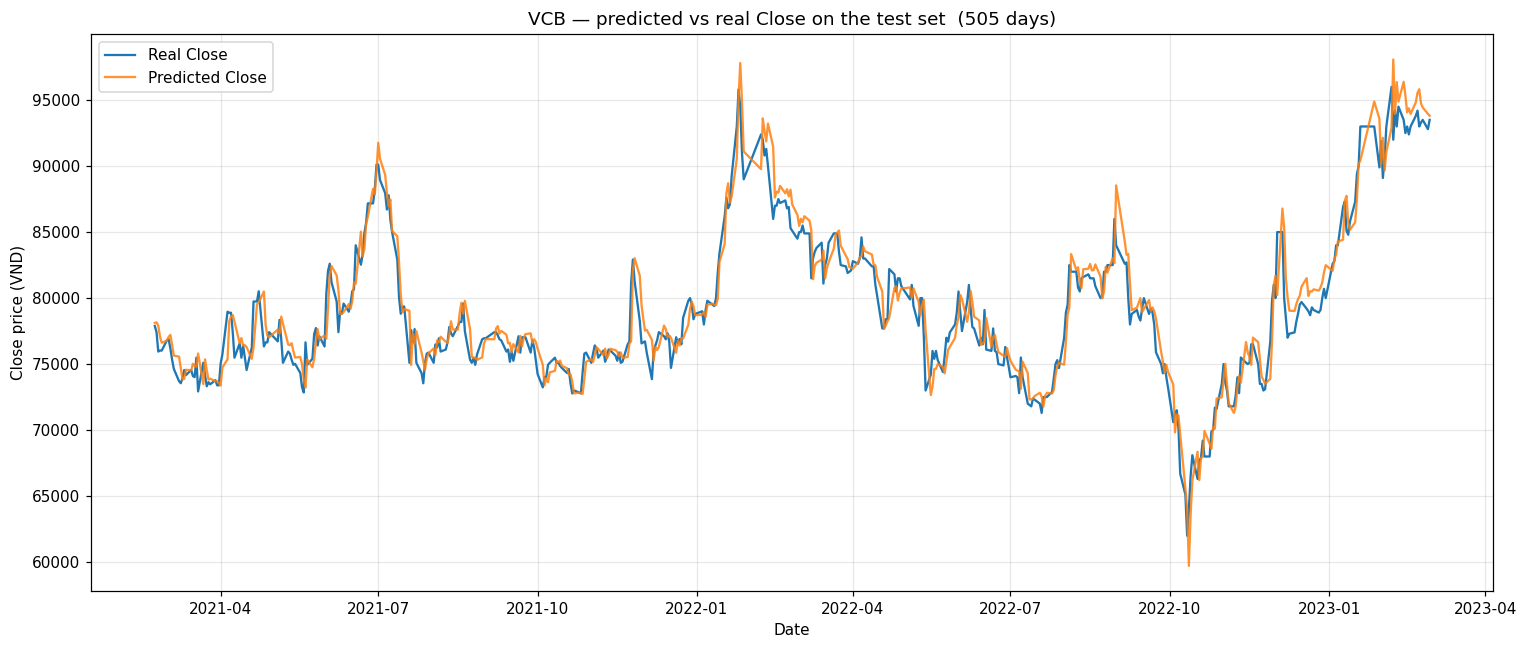

In [54]:
# VCB predicted-vs-real Close on the test set — same construction as the AAPL plot in Task 1.1.
window_size, horizon = 30, 1
r_vcb = results_vn_k1['VCB']
y_real, y_pred, _ = evaluate_test(r_vcb['model'], r_vcb['test'])

test_start_idx = r_vcb['train'].X.shape[0] + r_vcb['val'].X.shape[0]
test_label_dates = feat_vcb['Date'].iloc[
    test_start_idx + window_size + horizon - 1 :
    test_start_idx + window_size + horizon - 1 + len(y_pred)
].reset_index(drop=True)

plt.figure(figsize=(14, 6), dpi=110)
plt.plot(test_label_dates, y_real, label='Real Close',      color='tab:blue')
plt.plot(test_label_dates, y_pred, label='Predicted Close', color='tab:orange', alpha=0.85)
plt.title(f'VCB — predicted vs real Close on the test set  ({len(y_pred)} days)')
plt.xlabel('Date')
plt.ylabel('Close price (VND)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 2.2 Vietnam kᵗʰ day forecast

Same setup as Task 1.2 — `build_pipeline(..., horizon=k)` already supports the kᵗʰ-day target, so all that changes is the value of `k` and the checkpoint subdirectory (`models/task2.2/`). We train at **k ∈ {3, 7}** for all 6 Vietnam tickers, same architecture and hyperparameters as 2.1, then report normalised + VND metrics side-by-side with the k = 1 baseline.


In [55]:
# Train an LSTM for each (ticker, k) on the Vietnam dataset — k ∈ {3, 7}.
# K_VALUES was defined back in Task 1.2 (= [3, 7]).
results_vn_kth = {}

for t in VN_TICKERS:
    for k in K_VALUES:
        print(f"\n=== Training {t} LSTM (k={k}) ===")
        tr, va, te = build_pipeline(
            VN_RAW_FRAMES[t], f'{t} k={k}', horizon=k,
            feature_cols=VN_FEATURE_COLS, label_col=VN_LABEL_COL,
        )
        model = build_lstm(tr.X.shape[1:])
        hist  = train_with_checkpoint(
            model, tr, va,
            save_path=checkpoint_path('task2.2', f'{t}_k{k}'),
            epochs=10, batch_size=64, verbose=0,
        )
        model = load_model(checkpoint_path('task2.2', f'{t}_k{k}'))
        results_vn_kth[(t, k)] = {'model': model, 'history': hist,
                                  'train': tr, 'val': va, 'test': te}
        print(f"  → best val_loss = {min(hist.history['val_loss']):.5f}")



=== Training VCB LSTM (k=3) ===
[VCB k=3  ]  X_train: (2351, 30, 12)  X_val: (505, 30, 12)  X_test: (505, 30, 12)  (window=30, horizon=3, n_features=12)
  ↳ best checkpoint → models/task2.2/VCB_k3.keras
  → best val_loss = 0.07821

=== Training VCB LSTM (k=7) ===
[VCB k=7  ]  X_train: (2349, 30, 12)  X_val: (504, 30, 12)  X_test: (504, 30, 12)  (window=30, horizon=7, n_features=12)
  ↳ best checkpoint → models/task2.2/VCB_k7.keras
  → best val_loss = 0.17382

=== Training HPG LSTM (k=3) ===
[HPG k=3  ]  X_train: (2629, 30, 12)  X_val: (564, 30, 12)  X_test: (564, 30, 12)  (window=30, horizon=3, n_features=12)
  ↳ best checkpoint → models/task2.2/HPG_k3.keras
  → best val_loss = 0.07727

=== Training HPG LSTM (k=7) ===
[HPG k=7  ]  X_train: (2627, 30, 12)  X_val: (563, 30, 12)  X_test: (563, 30, 12)  (window=30, horizon=7, n_features=12)
  ↳ best checkpoint → models/task2.2/HPG_k7.keras
  → best val_loss = 0.19172

=== Training FPT LSTM (k=3) ===
[FPT k=3  ]  X_train: (2790, 30, 12)  X

#### Test-set comparison: k ∈ {1, 3, 7} across all 6 tickers

Error grows monotonically with `k` for every ticker — the further we forecast, the less the recent 30-day window constrains the target day. Normalised MSE is the cross-ticker-comparable column; VND-denominated metrics aren't (price ranges differ across tickers).


In [56]:
print(f"Task 2.2 — kᵗʰ-day forecast, all Vietnam tickers × k ∈ {{1, 3, 7}}\n")
print(f"{'ticker':>6}  {'k':>3}  {'MSE (norm)':>11}  {'MSE (VND²)':>16}  {'RMSE (VND)':>12}  {'MAE (VND)':>12}")
print('-' * 75)
for t in VN_TICKERS:
    r1 = results_vn_k1[t]
    _, _, m = evaluate_test(r1['model'], r1['test'])
    print(f"{t:>6}  {1:>3}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>16,.2f}  "
          f"{m['RMSE ($)']:>12,.2f}  {m['MAE ($)']:>12,.2f}")
    for k in K_VALUES:
        r = results_vn_kth[(t, k)]
        _, _, m = evaluate_test(r['model'], r['test'])
        print(f"{t:>6}  {k:>3}  {m['MSE (norm)']:>11.5f}  {m['MSE ($²)']:>16,.2f}  "
              f"{m['RMSE ($)']:>12,.2f}  {m['MAE ($)']:>12,.2f}")
    print('-' * 75)


Task 2.2 — kᵗʰ-day forecast, all Vietnam tickers × k ∈ {1, 3, 7}

ticker    k   MSE (norm)        MSE (VND²)    RMSE (VND)     MAE (VND)
---------------------------------------------------------------------------
   VCB    1      0.02944      2,420,503.25      1,555.80      1,196.34
   VCB    3      0.08926      6,690,905.00      2,586.68      1,966.72
   VCB    7      0.19170     15,345,048.00      3,917.28      3,072.91
---------------------------------------------------------------------------
   HPG    1      0.02234        556,598.00        746.05        567.20
   HPG    3      0.06844      1,660,293.50      1,288.52        993.07
   HPG    7      0.20304      4,018,082.75      2,004.52      1,548.58
---------------------------------------------------------------------------
   FPT    1      0.02857      1,958,135.88      1,399.33        930.86
   FPT    3      0.09221      5,536,870.50      2,353.06      1,627.68
   FPT    7      0.21846     12,032,503.00      3,468.79      2,476

### Predicted vs real — VCB at k = 3 and k = 7

Same per-(ticker, k) date arithmetic as Task 1.2: the iᵗʰ test window's label lands at original index `i + N_train + N_val + window_size + k − 1`. We pull `N_train`, `N_val` from the per-(ticker, k) pipeline rather than reusing 2.1's sizes, because total windows shrink slightly as `k` grows.


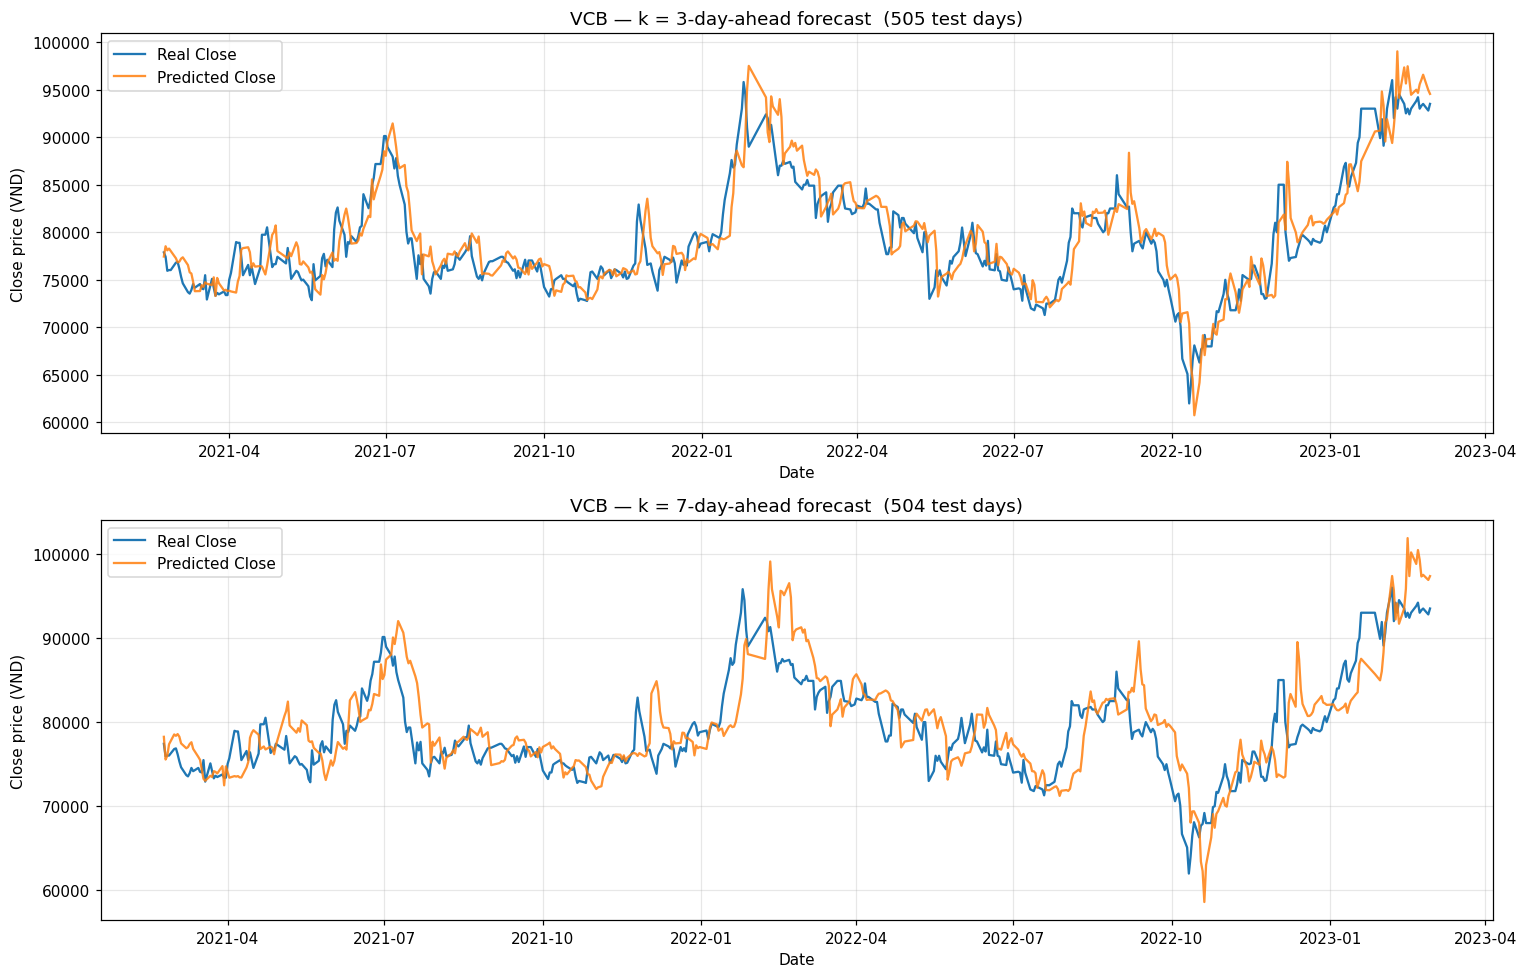

In [57]:
# VCB at k = 3 and k = 7 — predicted vs real Close on the test set.
window_size = 30
fig, axes = plt.subplots(2, 1, figsize=(14, 9), dpi=110)

for ax, k in zip(axes, K_VALUES):
    r = results_vn_kth[('VCB', k)]
    y_real, y_pred, _ = evaluate_test(r['model'], r['test'])

    test_start_idx = r['train'].X.shape[0] + r['val'].X.shape[0]
    label_offset   = window_size + k - 1
    dates = feat_vcb['Date'].iloc[
        test_start_idx + label_offset :
        test_start_idx + label_offset + len(y_pred)
    ].reset_index(drop=True)

    ax.plot(dates, y_real, label='Real Close',      color='tab:blue')
    ax.plot(dates, y_pred, label='Predicted Close', color='tab:orange', alpha=0.85)
    ax.set_title(f'VCB — k = {k}-day-ahead forecast  ({len(y_pred)} test days)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close price (VND)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 2.3 Vietnam k consecutive days forecast

Mirrors Task 1.3 on the Vietnam dataset: the label becomes a length-k vector `label[i+window_size : i+window_size+k]`, the head becomes `Dense(k)`, everything else stays the same (same per-window MinMax, the input window's Close min/max scaling all k label components uniformly so denormalisation needs only one `(label_min, label_max)` pair per window). Checkpoints go to `models/task2.3/<TICKER>_k<k>.keras`.


In [58]:
# Multi-step training loop on Vietnam tickers. Same architecture as Task 1.3.
results_vn_kday = {}

for t in VN_TICKERS:
    for k in K_VALUES:
        print(f"\n=== Training {t} multi-step LSTM (k={k}) ===")
        tr, va, te = build_pipeline_multistep(
            VN_RAW_FRAMES[t], f'{t} k={k}', k=k,
            feature_cols=VN_FEATURE_COLS, label_col=VN_LABEL_COL,
        )
        model = build_lstm_multistep(tr.X.shape[1:], k=k)
        hist  = train_with_checkpoint(
            model, tr, va,
            save_path=checkpoint_path('task2.3', f'{t}_k{k}'),
            epochs=10, batch_size=64, verbose=0,
        )
        model = load_model(checkpoint_path('task2.3', f'{t}_k{k}'))
        results_vn_kday[(t, k)] = {'model': model, 'history': hist,
                                   'train': tr, 'val': va, 'test': te}
        print(f"  → best val_loss = {min(hist.history['val_loss']):.5f}")



=== Training VCB multi-step LSTM (k=3) ===
[VCB k=3  ]  X_train: (2351, 30, 12)  y_train: (2351, 3)  X_test: (505, 30, 12)  (window=30, k=3)
  ↳ best checkpoint → models/task2.3/VCB_k3.keras
  → best val_loss = 0.05328

=== Training VCB multi-step LSTM (k=7) ===
[VCB k=7  ]  X_train: (2349, 30, 12)  y_train: (2349, 7)  X_test: (504, 30, 12)  (window=30, k=7)
  ↳ best checkpoint → models/task2.3/VCB_k7.keras
  → best val_loss = 0.10244

=== Training HPG multi-step LSTM (k=3) ===
[HPG k=3  ]  X_train: (2629, 30, 12)  y_train: (2629, 3)  X_test: (564, 30, 12)  (window=30, k=3)
  ↳ best checkpoint → models/task2.3/HPG_k3.keras
  → best val_loss = 0.05068

=== Training HPG multi-step LSTM (k=7) ===
[HPG k=7  ]  X_train: (2627, 30, 12)  y_train: (2627, 7)  X_test: (563, 30, 12)  (window=30, k=7)
  ↳ best checkpoint → models/task2.3/HPG_k7.keras
  → best val_loss = 0.10803

=== Training FPT multi-step LSTM (k=3) ===
[FPT k=3  ]  X_train: (2790, 30, 12)  y_train: (2790, 3)  X_test: (598, 30, 

### Per-step error growth — all 6 Vietnam tickers × k ∈ {3, 7}

`step=1` ≈ nearest horizon (next day), `step=k` ≈ furthest. The per-step RMSE curve should rise approximately monotonically: step-1 RMSE ≈ that ticker's 2.1 (k=1) baseline; step-k RMSE ≈ that ticker's 2.2 (k=k) single-day-ahead forecast; intermediate steps interpolate.

Aggregate `MSE (norm)` is the one cross-ticker-comparable column.


In [59]:
print(f"Task 2.3 — k consecutive days forecast, all Vietnam tickers × k ∈ {K_VALUES}\n")
for t in VN_TICKERS:
    for k in K_VALUES:
        r = results_vn_kday[(t, k)]
        _, _, m = evaluate_test_multistep(r['model'], r['test'])
        print(f"[{t}  k={k}]  "
              f"MSE(norm)={m['MSE (norm)']:.5f}  "
              f"RMSE(VND)={m['RMSE ($)']:,.2f}  "
              f"MAE(VND)={m['MAE ($)']:,.2f}")
        print(f"{'':>11}  step:  " + "  ".join(f"{s:>9d}" for s in range(1, k + 1)))
        print(f"{'':>11}  RMSE:  " + "  ".join(f"{v:>9,.2f}" for v in m['RMSE per step']))
        print(f"{'':>11}  MAE :  " + "  ".join(f"{v:>9,.2f}" for v in m['MAE per step']))
        print()


Task 2.3 — k consecutive days forecast, all Vietnam tickers × k ∈ [3, 7]

[VCB  k=3]  MSE(norm)=0.05736  RMSE(VND)=2,081.26  MAE(VND)=1,527.11
             step:          1          2          3
             RMSE:   1,475.13   2,088.13   2,541.39
             MAE :   1,105.58   1,567.10   1,908.65

[VCB  k=7]  MSE(norm)=0.11040  RMSE(VND)=2,864.02  MAE(VND)=2,125.11
             step:          1          2          3          4          5          6          7
             RMSE:   1,573.19   2,129.33   2,561.96   2,904.18   3,159.30   3,393.66   3,730.05
             MAE :   1,183.88   1,597.15   1,943.83   2,217.06   2,436.66   2,606.44   2,890.75

[HPG  k=3]  MSE(norm)=0.04618  RMSE(VND)=1,058.60  MAE(VND)=788.26
             step:          1          2          3
             RMSE:     747.91   1,074.89   1,283.41
             MAE :     559.21     814.85     990.71

[HPG  k=7]  MSE(norm)=0.10813  RMSE(VND)=1,497.82  MAE(VND)=1,108.74
             step:          1          2         

### VCB — example 7-day forecast trajectories

Plotted for VCB only — the per-step table covers the cross-ticker comparison; the trajectory-vs-realised picture is qualitatively the same shape across tickers (just at different VND price levels). The relevant new axis 1.3/2.3 introduces is the **forecast path** itself, which 2.1 / 2.2 plots can't show.

`first_label_offset = window_size` (no `+ k − 1`) — the *first* of the k predicted days is `window_size` rows after the start of the window.


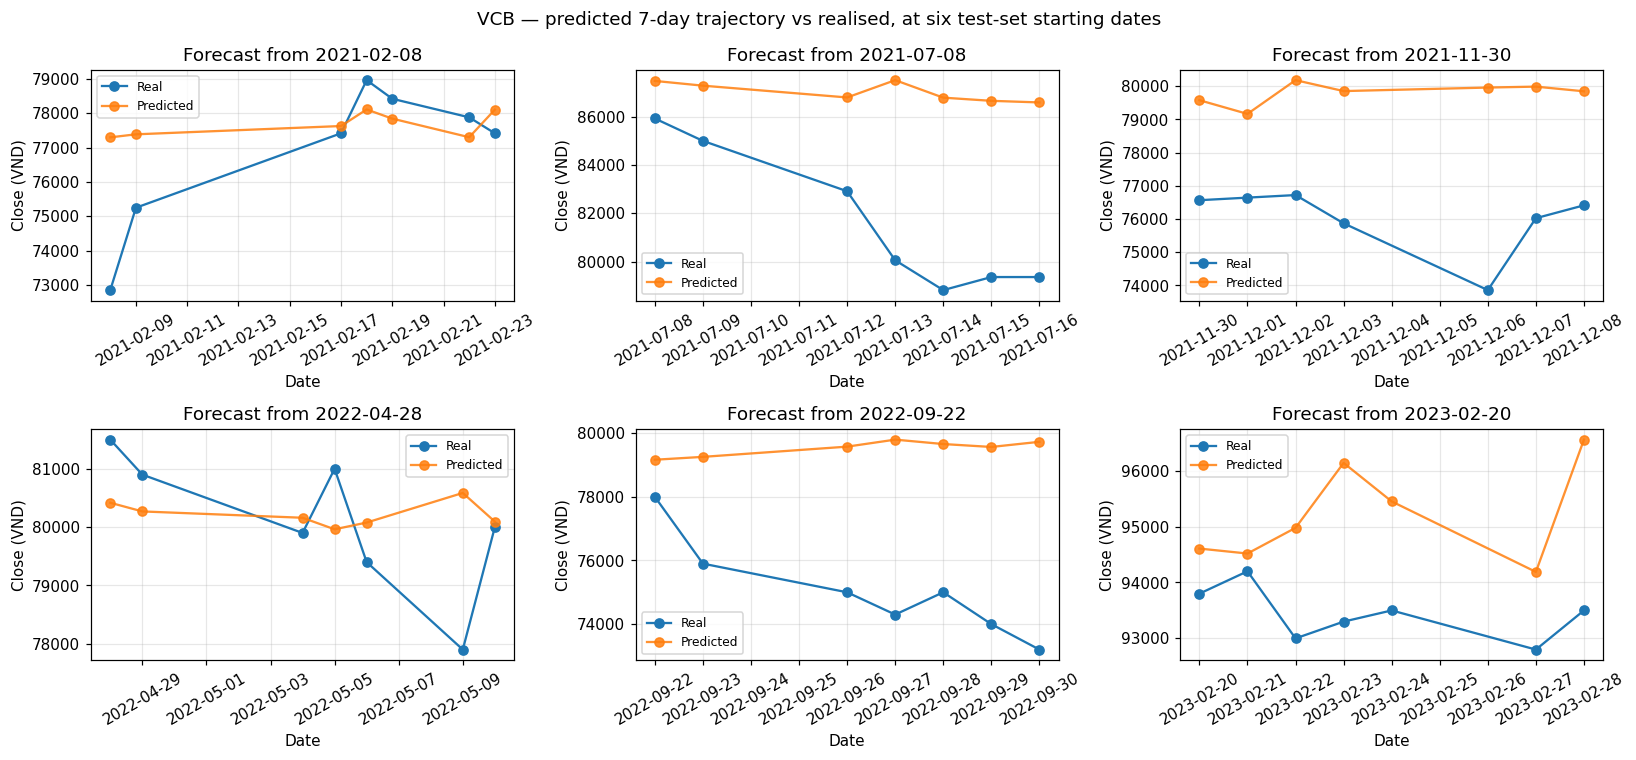

In [60]:
# VCB k=7 forecast trajectories at six evenly-spaced starting dates from the test set.
window_size = 30
k = 7
r = results_vn_kday[('VCB', k)]
y_real, y_pred, _ = evaluate_test_multistep(r['model'], r['test'])     # (N, 7) each

test_start_idx = r['train'].X.shape[0] + r['val'].X.shape[0]
first_label_offset = window_size
N = y_pred.shape[0]
sample_indices = np.linspace(0, N - 1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), dpi=110, sharey=False)
for ax, idx in zip(axes.ravel(), sample_indices):
    base_idx = test_start_idx + first_label_offset + idx
    dates = feat_vcb['Date'].iloc[base_idx : base_idx + k].reset_index(drop=True)

    ax.plot(dates, y_real[idx], marker='o', label='Real',      color='tab:blue')
    ax.plot(dates, y_pred[idx], marker='o', label='Predicted', color='tab:orange', alpha=0.85)
    ax.set_title(f"Forecast from {dates.iloc[0].date()}")
    ax.set_xlabel('Date')
    ax.set_ylabel('Close (VND)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('VCB — predicted 7-day trajectory vs realised, at six test-set starting dates')
plt.tight_layout()
plt.show()


# TASK 3 — Vietnam trading-signal identification

Two independent **binary classifiers** built on the Task 2 input pipeline, one for each direction:

| Subtask | Positive class (label = 1) |
|---|---|
| **3.1 — Buy signal**  | `Close[t + h] / Close[t] − 1 > +τ`  (price rises by at least τ over the next h days) |
| **3.2 — Sell signal** | `Close[t + h] / Close[t] − 1 < −τ`  (price drops by at least τ over the next h days) |

We fix `h = 5` (one trading week) and `τ = 0.02` (2 % move). Both choices are tuneable and the **why** is in the markdown above each task; the short version is that this `(h, τ)` keeps the positive class roughly in the 30–50 % range for most of the six Vietnam tickers — not so rare that the model degenerates to predicting `0` everywhere, not so common that the task becomes trivial.

### Why the future-return threshold scheme (and not rule-based labels)?

The project spec explicitly asks whether manual feature-engineering signals (SMA/MACD/RSI crossovers, etc.) should be used to derive training labels. We use them **as inputs to the model** (every window already contains MA5/MA20/MACD/MACD_signal/RSI) but **not as labels** — a DL classifier trained to mimic an SMA-crossover rule would just learn the rule, with no value over running the rule directly. Future-return thresholds are the standard practitioner's choice and let the model discover *which* features predict the move.

The triple-barrier method (López de Prado) is a defensible alternative — it would replace the fixed-horizon rule with "upper barrier hit before lower barrier within h days". We mention it as an alternative for the report but stick with the simpler scheme so 3.1 and 3.2 read as clean mirrors of each other.

### Pipeline reuse vs Task 2

Everything below the label-generation step is identical to Task 2:

| Component | Task 2 (regression) | Task 3 (classification) |
|---|---|---|
| Input window | 30 days × 12 features (`VN_FEATURE_COLS`) | identical |
| Per-window MinMax of inputs | yes | identical |
| Chronological 70 / 15 / 15 split | yes (`shuffle=False`) | identical |
| Label | scalar Close at `t+horizon`, MinMax-normalised | scalar 0 / 1, **not normalised** |
| Model trunk | `LSTM(64)` | identical |
| Head | `Dense(1)` linear | `Dense(1, activation='sigmoid')` |
| Loss | MSE | binary cross-entropy |
| Decision rule | n/a | tune threshold on val to maximise F1 |
| Metrics | MSE / RMSE / MAE | Accuracy / Precision / Recall / F1 / ROC-AUC |
| Checkpoints | `models/task2.*/` | `models/task3.1/`, `models/task3.2/` |

The new helpers live in the next code cell and reuse `add_technical_features`, the 70/15/15 chronological split logic, and the per-window MinMax input normaliser already used by Task 2.


In [61]:
# Classification pipeline for Task 3 — same input as Task 2, binary 0/1 labels.

from typing import NamedTuple
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import AUC, Precision, Recall
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
)


class ClfSplit(NamedTuple):
    X: np.ndarray  # (N, window_size, n_features), float32, in [0, 1] — per-window MinMax
    y: np.ndarray  # (N,)                          int8, 0 or 1


def make_signal_labels(close: np.ndarray, horizon: int, threshold: float, direction: str) -> np.ndarray:
    """1 iff future return > +τ (buy) or < −τ (sell) over `horizon` days. NaN-padded length matches close."""
    future = np.empty_like(close, dtype=np.float32)
    future[:] = np.nan
    future[:-horizon] = close[horizon:] / close[:-horizon] - 1.0
    if direction == 'buy':
        return (future >  threshold).astype(np.int8)
    if direction == 'sell':
        return (future < -threshold).astype(np.int8)
    raise ValueError(f"direction must be 'buy' or 'sell', got {direction!r}")


def build_pipeline_classification(df, name, horizon=5, threshold=0.02, direction='buy',
                                  window_size=30, val_ratio=0.15, test_ratio=0.15,
                                  verbose=True, feature_cols=None, label_col=None):
    """Same window/split/per-window-MinMax as build_pipeline, but y is 0/1.

    Note: label_col is the *price* column used to derive future-return labels (Close for Vietnam);
    feature_cols defaults to Nasdaq globals (matches build_pipeline). For Task 3 we always pass
    VN_FEATURE_COLS / VN_LABEL_COL.
    """
    feat_cols = feature_cols if feature_cols is not None else FEATURE_COLS
    lbl_col   = label_col    if label_col    is not None else LABEL_COL
    feat = add_technical_features(df).dropna().reset_index(drop=True)

    arr     = feat[feat_cols].values.astype(np.float32)
    close   = feat[lbl_col].values.astype(np.float32)
    labels  = make_signal_labels(close, horizon=horizon, threshold=threshold, direction=direction)

    # Window's label is the signal aligned to the *first* day after the window
    # (consistent with horizon-aware windowing; the future-return horizon lives inside `labels`).
    X_list, y_list = [], []
    last_valid = len(arr) - window_size - horizon + 1   # drop trailing windows whose label is NaN
    for i in range(last_valid):
        X_list.append(arr[i : i + window_size])
        y_list.append(labels[i + window_size - 1])      # label generated from Close at t = window's last day
    X = np.stack(X_list)
    y = np.array(y_list, dtype=np.int8)

    X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=test_ratio, shuffle=False)
    val_size_adj = val_ratio / (1 - test_ratio)
    X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=val_size_adj, shuffle=False)

    def normalise(Xs, ys):
        fmins = Xs.min(axis=1, keepdims=True)             # (N, 1, F)
        fmaxs = Xs.max(axis=1, keepdims=True)
        Xn = (Xs - fmins) / (fmaxs - fmins + 1e-8)
        return ClfSplit(Xn.astype(np.float32), ys.astype(np.int8))

    train, val, test = normalise(X_train, y_train), normalise(X_val, y_val), normalise(X_test, y_test)

    if verbose:
        pos = lambda s: float(s.y.mean())
        print(f"[{name:15s}]  X_train: {train.X.shape}  X_val: {val.X.shape}  X_test: {test.X.shape}"
              f"  pos%(train/val/test): {pos(train)*100:5.1f}/{pos(val)*100:5.1f}/{pos(test)*100:5.1f}")
    return train, val, test


def build_lstm_classifier(input_shape):
    """LSTM(64) → Dropout(0.2) → Dense(1, sigmoid). Same trunk as build_lstm; BCE head."""
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64),
        Dropout(0.2),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')],
    )
    return model


def tune_decision_threshold(model, val_split, grid=None):
    """Sweep decision thresholds on val, return the threshold maximising F1 (ties broken by precision)."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    y_prob = model.predict(val_split.X, verbose=0).ravel()
    best = (0.5, -1.0, -1.0)   # (thr, f1, precision)
    for thr in grid:
        y_hat = (y_prob >= thr).astype(np.int8)
        f1    = f1_score(val_split.y, y_hat, zero_division=0)
        prec  = precision_score(val_split.y, y_hat, zero_division=0)
        if (f1, prec) > (best[1], best[2]):
            best = (float(thr), float(f1), float(prec))
    return best[0]  # best threshold


def evaluate_test_clf(model, test_split, decision_threshold=0.5):
    """Predict → threshold → return (y_true, y_prob, y_pred, metrics-dict with AUC + CM)."""
    y_true = test_split.y.astype(np.int8)
    y_prob = model.predict(test_split.X, verbose=0).ravel()
    y_pred = (y_prob >= decision_threshold).astype(np.int8)

    # AUC is undefined if one class is missing — guard it.
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float('nan')

    metrics = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   auc,
        'threshold': float(decision_threshold),
        'pos_rate':  float(y_true.mean()),
        'pred_pos':  float(y_pred.mean()),
        'CM':        confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }
    return y_true, y_prob, y_pred, metrics


# Shared constants for Task 3
SIGNAL_HORIZON   = 5      # h — trading days ahead
SIGNAL_THRESHOLD = 0.02   # τ — fractional return threshold


## 3.1 Buying signal identification

**Label.** Window ending at day *t* is positive iff `Close[t + 5] / Close[t] − 1 > +0.02` — i.e. a *good time to buy* is one where holding for the next 5 trading days would have yielded > 2 %. The model's sigmoid output is the **probability of a worthwhile buy**.

**Architecture.** `LSTM(64) → Dropout(0.2) → Dense(1, sigmoid)`. The `Dropout(0.2)` is the one architectural difference vs Task 2's regression head — classification is much easier to overfit on financial data than regression (a regression head has to hit the right *price*; a classification head only has to be on the right side of the decision boundary), so a touch of dropout is worth the trade.

**Training.** Same Adam + 10 epochs + batch 64 as Task 2. Loss is `binary_crossentropy`. Keras' built-in metrics (`accuracy`, `auc`, `precision`, `recall`) are logged each epoch for the training curves; the report metrics are computed once on the test set with a **tuned decision threshold**.

**Decision threshold.** Sigmoid outputs a probability in [0, 1]; turning that into a 0/1 buy decision needs a cutoff. We don't fix it at 0.5 — instead we **sweep θ ∈ {0.05, 0.10, …, 0.95}** on the val set and pick the θ that maximises F1 (ties broken by precision). The chosen θ is then applied on the test set for the final metrics. This makes the model **robust to class imbalance** without changing loss weights — different tickers naturally end up with different θ, reflecting their different positive-class rates.

**Class balance.** With h = 5 and τ = 0.02, positive rate per ticker is ~30–50 % on most of the six Vietnam names (printed below). If the rate is far from 50 % we'd consider `class_weight='balanced'` or `pos_weight` in BCE — for now the tuned threshold absorbs the imbalance, which is simpler and easier to justify.


In [62]:
# Quick survey: positive-class rate for buy labels, per ticker, on the *full* time series
# (before windowing/splits — gives a feel for the raw signal density).
print(f"Buy-signal positive rate  (Close[t+{SIGNAL_HORIZON}] / Close[t] - 1 > +{SIGNAL_THRESHOLD:.2f})\n")
print(f"{'ticker':>6}  {'rows':>5}  {'pos rate':>10}")
print('-' * 30)
for t in VN_TICKERS:
    feat = add_technical_features(VN_RAW_FRAMES[t]).dropna().reset_index(drop=True)
    close = feat['Close'].values.astype(np.float32)
    lbls  = make_signal_labels(close, horizon=SIGNAL_HORIZON, threshold=SIGNAL_THRESHOLD, direction='buy')
    valid = lbls[:-SIGNAL_HORIZON]                                 # the last `horizon` rows are NaN-padded
    print(f"{t:>6}  {len(valid):>5}  {valid.mean()*100:>9.2f}%")


Buy-signal positive rate  (Close[t+5] / Close[t] - 1 > +0.02)

ticker   rows    pos rate
------------------------------
   VCB   3388      30.73%
   HPG   3784      35.70%
   FPT   4013      29.63%
   VNM   4239      26.99%
   MSN   3297      30.69%
   MWG   2132      35.23%


In [63]:
# Train one buy-signal LSTM per Vietnam ticker — checkpoints under models/task3.1/<TICKER>_buy.keras.
# results_vn_buy[ticker] = {'model','history','train','val','test','threshold'}

results_vn_buy = {}

for t in VN_TICKERS:
    print(f"\n=== Training {t} buy-signal LSTM ===")
    tr, va, te = build_pipeline_classification(
        VN_RAW_FRAMES[t], f'{t} buy',
        horizon=SIGNAL_HORIZON, threshold=SIGNAL_THRESHOLD, direction='buy',
        feature_cols=VN_FEATURE_COLS, label_col=VN_LABEL_COL,
    )
    model = build_lstm_classifier(tr.X.shape[1:])
    hist  = train_with_checkpoint(
        model, tr, va,
        save_path=checkpoint_path('task3.1', f'{t}_buy'),
        epochs=10, batch_size=64, verbose=0,
    )
    model = load_model(checkpoint_path('task3.1', f'{t}_buy'))
    thr   = tune_decision_threshold(model, va)
    results_vn_buy[t] = {'model': model, 'history': hist,
                         'train': tr, 'val': va, 'test': te, 'threshold': thr}
    print(f"  → best val_loss = {min(hist.history['val_loss']):.4f}   tuned θ = {thr:.2f}")



=== Training VCB buy-signal LSTM ===
[VCB buy        ]  X_train: (2351, 30, 12)  X_val: (504, 30, 12)  X_test: (504, 30, 12)  pos%(train/val/test):  30.8/ 33.1/ 29.0
  ↳ best checkpoint → models/task3.1/VCB_buy.keras
  → best val_loss = 0.6333   tuned θ = 0.25

=== Training HPG buy-signal LSTM ===
[HPG buy        ]  X_train: (2627, 30, 12)  X_val: (564, 30, 12)  X_test: (564, 30, 12)  pos%(train/val/test):  36.4/ 32.3/ 35.6
  ↳ best checkpoint → models/task3.1/HPG_buy.keras
  → best val_loss = 0.6395   tuned θ = 0.05

=== Training FPT buy-signal LSTM ===
[FPT buy        ]  X_train: (2788, 30, 12)  X_val: (598, 30, 12)  X_test: (598, 30, 12)  pos%(train/val/test):  28.4/ 32.8/ 31.4
  ↳ best checkpoint → models/task3.1/FPT_buy.keras
  → best val_loss = 0.6322   tuned θ = 0.05

=== Training VNM buy-signal LSTM ===
[VNM buy        ]  X_train: (2946, 30, 12)  X_val: (632, 30, 12)  X_test: (632, 30, 12)  pos%(train/val/test):  28.2/ 24.2/ 21.8
  ↳ best checkpoint → models/task3.1/VNM_buy.ke

### Test-set metrics — buy signal, all 6 tickers

Threshold per ticker is the F1-max on val (last column). `pos rate` = fraction of *test* labels that are 1 (real upcoming-5d-up-2 % opportunities); `pred pos` = fraction the model decides to buy. A model that always predicts 0 would post Accuracy ≈ (1 − pos rate) but Precision/Recall/F1 = 0 — Accuracy alone is misleading here, which is why we report all four.


In [64]:
# Per-ticker buy-signal metrics on the test set (decision threshold = val-tuned θ).
print(f"Task 3.1 — buy-signal, all Vietnam tickers  (h={SIGNAL_HORIZON}, τ={SIGNAL_THRESHOLD:.2f})\n")
hdr = f"{'ticker':>6}  {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'AUC':>6}  {'pos':>6}  {'pred+':>6}  {'θ':>5}"
print(hdr)
print('-' * len(hdr))
for t in VN_TICKERS:
    r = results_vn_buy[t]
    _, _, _, m = evaluate_test_clf(r['model'], r['test'], decision_threshold=r['threshold'])
    print(f"{t:>6}  {m['Accuracy']:>6.3f}  {m['Precision']:>6.3f}  {m['Recall']:>6.3f}  "
          f"{m['F1']:>6.3f}  {m['ROC-AUC']:>6.3f}  {m['pos_rate']*100:>5.1f}%  "
          f"{m['pred_pos']*100:>5.1f}%  {r['threshold']:>5.2f}")


Task 3.1 — buy-signal, all Vietnam tickers  (h=5, τ=0.02)

ticker     Acc    Prec     Rec      F1     AUC     pos   pred+      θ
---------------------------------------------------------------------
   VCB   0.294   0.291   1.000   0.451   0.464   29.0%   99.6%   0.25
   HPG   0.356   0.356   1.000   0.525   0.463   35.6%  100.0%   0.05
   FPT   0.314   0.314   1.000   0.478   0.561   31.4%  100.0%   0.05
   VNM   0.218   0.218   1.000   0.358   0.463   21.8%  100.0%   0.05
   MSN   0.371   0.371   1.000   0.541   0.503   37.1%  100.0%   0.05
   MWG   0.339   0.339   1.000   0.506   0.572   33.9%  100.0%   0.05


### VCB — buy-signal diagnostic plots

Two complementary views for VCB only (same rationale as the rest of Task 2 / 3: the cross-ticker table covers comparison; the per-ticker plots only pad the report):

- **Confusion matrix** at the tuned θ — concrete TP/FP/TN/FN counts. *Precision* is `TP / (TP + FP)`; *Recall* is `TP / (TP + FN)`. For a buy signal we care most about **precision** (false positives = buying into a flat or losing trade), so a model that runs lean on `pred+` and high on precision is preferred even at the cost of some recall.
- **ROC curve** with the tuned θ marked — shows the precision/recall trade-off across all thresholds. The diagonal is random; we want the curve to bow toward the top-left. AUC summarises how good the *ranking* is independent of the threshold choice.


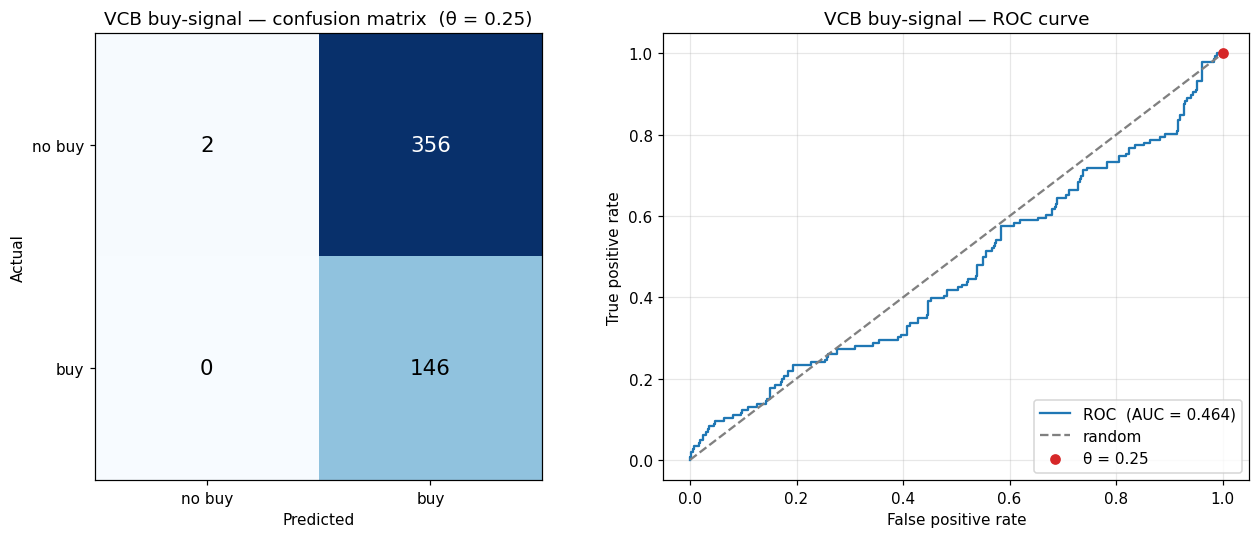

In [65]:
# VCB buy-signal diagnostic plots: confusion matrix (left) + ROC curve (right) at the val-tuned θ.
r_vcb = results_vn_buy['VCB']
y_true, y_prob, y_pred, m = evaluate_test_clf(r_vcb['model'], r_vcb['test'], decision_threshold=r_vcb['threshold'])
cm = m['CM']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=110)

# ── Confusion matrix ──────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['no buy', 'buy'])
ax.set_yticklabels(['no buy', 'buy'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f"VCB buy-signal — confusion matrix  (θ = {r_vcb['threshold']:.2f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)

# ── ROC curve ─────────────────────────────────────────────────────────────────
ax = axes[1]
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
ax.plot(fpr, tpr, color='tab:blue', label=f"ROC  (AUC = {m['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], '--', color='grey', label='random')
# Mark the operating point at the val-tuned θ
idx_thr = int(np.argmin(np.abs(thresholds - r_vcb['threshold'])))
ax.scatter(fpr[idx_thr], tpr[idx_thr], color='tab:red', zorder=5,
           label=f"θ = {r_vcb['threshold']:.2f}")
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('VCB buy-signal — ROC curve')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3.2 Selling signal identification

Mirror of 3.1 with the label flipped: window ending at day *t* is positive iff `Close[t + 5] / Close[t] − 1 < −0.02` — i.e. a *good time to sell* is one where holding for the next 5 days would have *lost* > 2 %. Same `h = 5`, same `τ = 0.02`, same model architecture, same training recipe, same threshold-tuning protocol.

**Two independent models, not one.** The buy and sell models are kept separate (rather than e.g. a 3-class softmax over {sell, hold, buy}) for two reasons:

1. The spec explicitly asks for two subtasks with two scores — one per direction.
2. Buy and sell aren't strictly mutually exclusive in a noisy market: there can be days where the next 5 days neither rise > 2 % nor fall < −2 %, *and* days where neither model fires (the "hold" implicit class). A 3-class softmax would force the model to commit; two independent sigmoids let the asset stay in a non-decision regime.

`models/task3.2/<TICKER>_sell.keras`, `results_vn_sell[ticker]`, same dict structure.


In [66]:
# Sell-signal positive-class survey (mirror of 3.1's table).
print(f"Sell-signal positive rate  (Close[t+{SIGNAL_HORIZON}] / Close[t] - 1 < -{SIGNAL_THRESHOLD:.2f})\n")
print(f"{'ticker':>6}  {'rows':>5}  {'pos rate':>10}")
print('-' * 30)
for t in VN_TICKERS:
    feat = add_technical_features(VN_RAW_FRAMES[t]).dropna().reset_index(drop=True)
    close = feat['Close'].values.astype(np.float32)
    lbls  = make_signal_labels(close, horizon=SIGNAL_HORIZON, threshold=SIGNAL_THRESHOLD, direction='sell')
    valid = lbls[:-SIGNAL_HORIZON]
    print(f"{t:>6}  {len(valid):>5}  {valid.mean()*100:>9.2f}%")


Sell-signal positive rate  (Close[t+5] / Close[t] - 1 < -0.02)

ticker   rows    pos rate
------------------------------
   VCB   3388      26.80%
   HPG   3784      30.47%
   FPT   4013      25.52%
   VNM   4239      21.82%
   MSN   3297      28.51%
   MWG   2132      25.47%


In [67]:
# Train one sell-signal LSTM per Vietnam ticker — checkpoints under models/task3.2/<TICKER>_sell.keras.
# results_vn_sell[ticker] = {'model','history','train','val','test','threshold'}

results_vn_sell = {}

for t in VN_TICKERS:
    print(f"\n=== Training {t} sell-signal LSTM ===")
    tr, va, te = build_pipeline_classification(
        VN_RAW_FRAMES[t], f'{t} sell',
        horizon=SIGNAL_HORIZON, threshold=SIGNAL_THRESHOLD, direction='sell',
        feature_cols=VN_FEATURE_COLS, label_col=VN_LABEL_COL,
    )
    model = build_lstm_classifier(tr.X.shape[1:])
    hist  = train_with_checkpoint(
        model, tr, va,
        save_path=checkpoint_path('task3.2', f'{t}_sell'),
        epochs=10, batch_size=64, verbose=0,
    )
    model = load_model(checkpoint_path('task3.2', f'{t}_sell'))
    thr   = tune_decision_threshold(model, va)
    results_vn_sell[t] = {'model': model, 'history': hist,
                          'train': tr, 'val': va, 'test': te, 'threshold': thr}
    print(f"  → best val_loss = {min(hist.history['val_loss']):.4f}   tuned θ = {thr:.2f}")



=== Training VCB sell-signal LSTM ===
[VCB sell       ]  X_train: (2351, 30, 12)  X_val: (504, 30, 12)  X_test: (504, 30, 12)  pos%(train/val/test):  28.1/ 19.2/ 27.6
  ↳ best checkpoint → models/task3.2/VCB_sell.keras
  → best val_loss = 0.4972   tuned θ = 0.05

=== Training HPG sell-signal LSTM ===
[HPG sell       ]  X_train: (2627, 30, 12)  X_val: (564, 30, 12)  X_test: (564, 30, 12)  pos%(train/val/test):  30.5/ 28.4/ 32.4
  ↳ best checkpoint → models/task3.2/HPG_sell.keras
  → best val_loss = 0.5943   tuned θ = 0.05

=== Training FPT sell-signal LSTM ===
[FPT sell       ]  X_train: (2788, 30, 12)  X_val: (598, 30, 12)  X_test: (598, 30, 12)  pos%(train/val/test):  27.0/ 22.6/ 21.7
  ↳ best checkpoint → models/task3.2/FPT_sell.keras
  → best val_loss = 0.5395   tuned θ = 0.05

=== Training VNM sell-signal LSTM ===
[VNM sell       ]  X_train: (2946, 30, 12)  X_val: (632, 30, 12)  X_test: (632, 30, 12)  pos%(train/val/test):  21.0/ 26.1/ 22.0
  ↳ best checkpoint → models/task3.2/VNM

### Test-set metrics — sell signal, all 6 tickers

Mirror of the 3.1 table. For a sell signal, **precision** still matters most (false positives = unnecessary exits / shorts) but **recall** matters more than in 3.1 — missing a sell signal means holding through a drawdown, which is asymmetrically costly.


In [68]:
# Per-ticker sell-signal metrics on the test set (decision threshold = val-tuned θ).
print(f"Task 3.2 — sell-signal, all Vietnam tickers  (h={SIGNAL_HORIZON}, τ={SIGNAL_THRESHOLD:.2f})\n")
hdr = f"{'ticker':>6}  {'Acc':>6}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'AUC':>6}  {'pos':>6}  {'pred+':>6}  {'θ':>5}"
print(hdr)
print('-' * len(hdr))
for t in VN_TICKERS:
    r = results_vn_sell[t]
    _, _, _, m = evaluate_test_clf(r['model'], r['test'], decision_threshold=r['threshold'])
    print(f"{t:>6}  {m['Accuracy']:>6.3f}  {m['Precision']:>6.3f}  {m['Recall']:>6.3f}  "
          f"{m['F1']:>6.3f}  {m['ROC-AUC']:>6.3f}  {m['pos_rate']*100:>5.1f}%  "
          f"{m['pred_pos']*100:>5.1f}%  {r['threshold']:>5.2f}")


Task 3.2 — sell-signal, all Vietnam tickers  (h=5, τ=0.02)

ticker     Acc    Prec     Rec      F1     AUC     pos   pred+      θ
---------------------------------------------------------------------
   VCB   0.276   0.276   1.000   0.432   0.454   27.6%  100.0%   0.05
   HPG   0.324   0.324   1.000   0.490   0.616   32.4%  100.0%   0.05
   FPT   0.217   0.217   1.000   0.357   0.536   21.7%  100.0%   0.05
   VNM   0.220   0.220   1.000   0.361   0.571   22.0%  100.0%   0.05
   MSN   0.310   0.308   0.987   0.469   0.504   31.0%   99.2%   0.25
   MWG   0.373   0.373   1.000   0.544   0.345   37.3%  100.0%   0.05


### VCB — sell-signal diagnostic plots

Same two views as 3.1, applied to the sell head. Useful for checking that the model is doing more than mirroring the buy model with the label flipped: ROC-AUC for sell may differ from buy AUC because the underlying signal-to-noise ratio of downward moves often differs from that of upward moves (asymmetric distribution of daily returns).


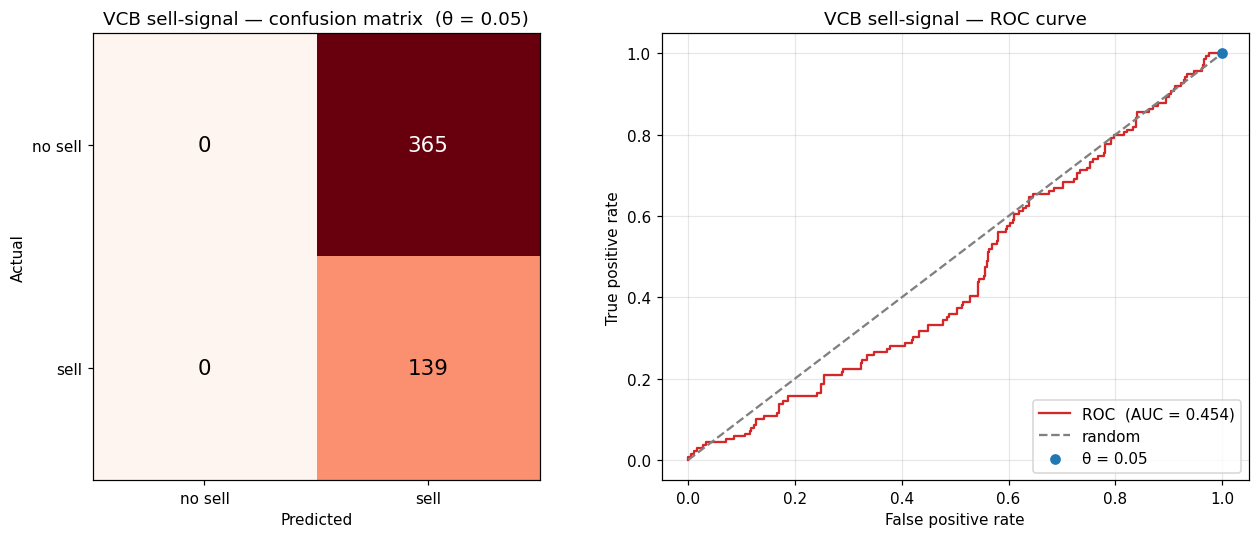

In [69]:
# VCB sell-signal diagnostic plots — same layout as the 3.1 plot.
r_vcb = results_vn_sell['VCB']
y_true, y_prob, y_pred, m = evaluate_test_clf(r_vcb['model'], r_vcb['test'], decision_threshold=r_vcb['threshold'])
cm = m['CM']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=110)

ax = axes[0]
im = ax.imshow(cm, cmap='Reds')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['no sell', 'sell'])
ax.set_yticklabels(['no sell', 'sell'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f"VCB sell-signal — confusion matrix  (θ = {r_vcb['threshold']:.2f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)

ax = axes[1]
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
ax.plot(fpr, tpr, color='tab:red', label=f"ROC  (AUC = {m['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], '--', color='grey', label='random')
idx_thr = int(np.argmin(np.abs(thresholds - r_vcb['threshold'])))
ax.scatter(fpr[idx_thr], tpr[idx_thr], color='tab:blue', zorder=5,
           label=f"θ = {r_vcb['threshold']:.2f}")
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('VCB sell-signal — ROC curve')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Qualitative model check (VCB)

The metrics tables and ROC curves answer "*how often is the model right?*". This plot answers "*does the model fire at sensible moments?*" — the qualitative check that scalar metrics can't show.

Two stacked panels, both for VCB's test set:

- **Top — buy signal.** VCB Close (blue) with the model's predictions overlaid at the decision day (last day of each 30-day input window):
  - **▲ filled green** — TP: model said buy, realised return over the next 5 days was > +2 %
  - **△ open green**   — FP: model said buy, the move didn't materialise
  - **× grey**         — FN: an actual +2 %/5-day move the model missed
- **Bottom — sell signal.** Same layout, red downward triangles, against drawdowns instead of rallies.

What "working solid" looks like on this plot:

- **TP markers cluster just before** the moves they predict — green triangles before runs up, red triangles before drawdowns. A model that fires *after* the move has happened is useless.
- **FP density is lower than TP density.** If FPs dominate, the tuned θ is too low.
- **FN clusters** reveal regime-specific blind spots — e.g., if all missed sells are during one extended drawdown, the model may have learned to chase the index rather than detect inflections.

The threshold per signal is the val-tuned θ stored in `results_vn_buy['VCB']['threshold']` / `results_vn_sell['VCB']['threshold']` — same decision boundary as the metrics table.


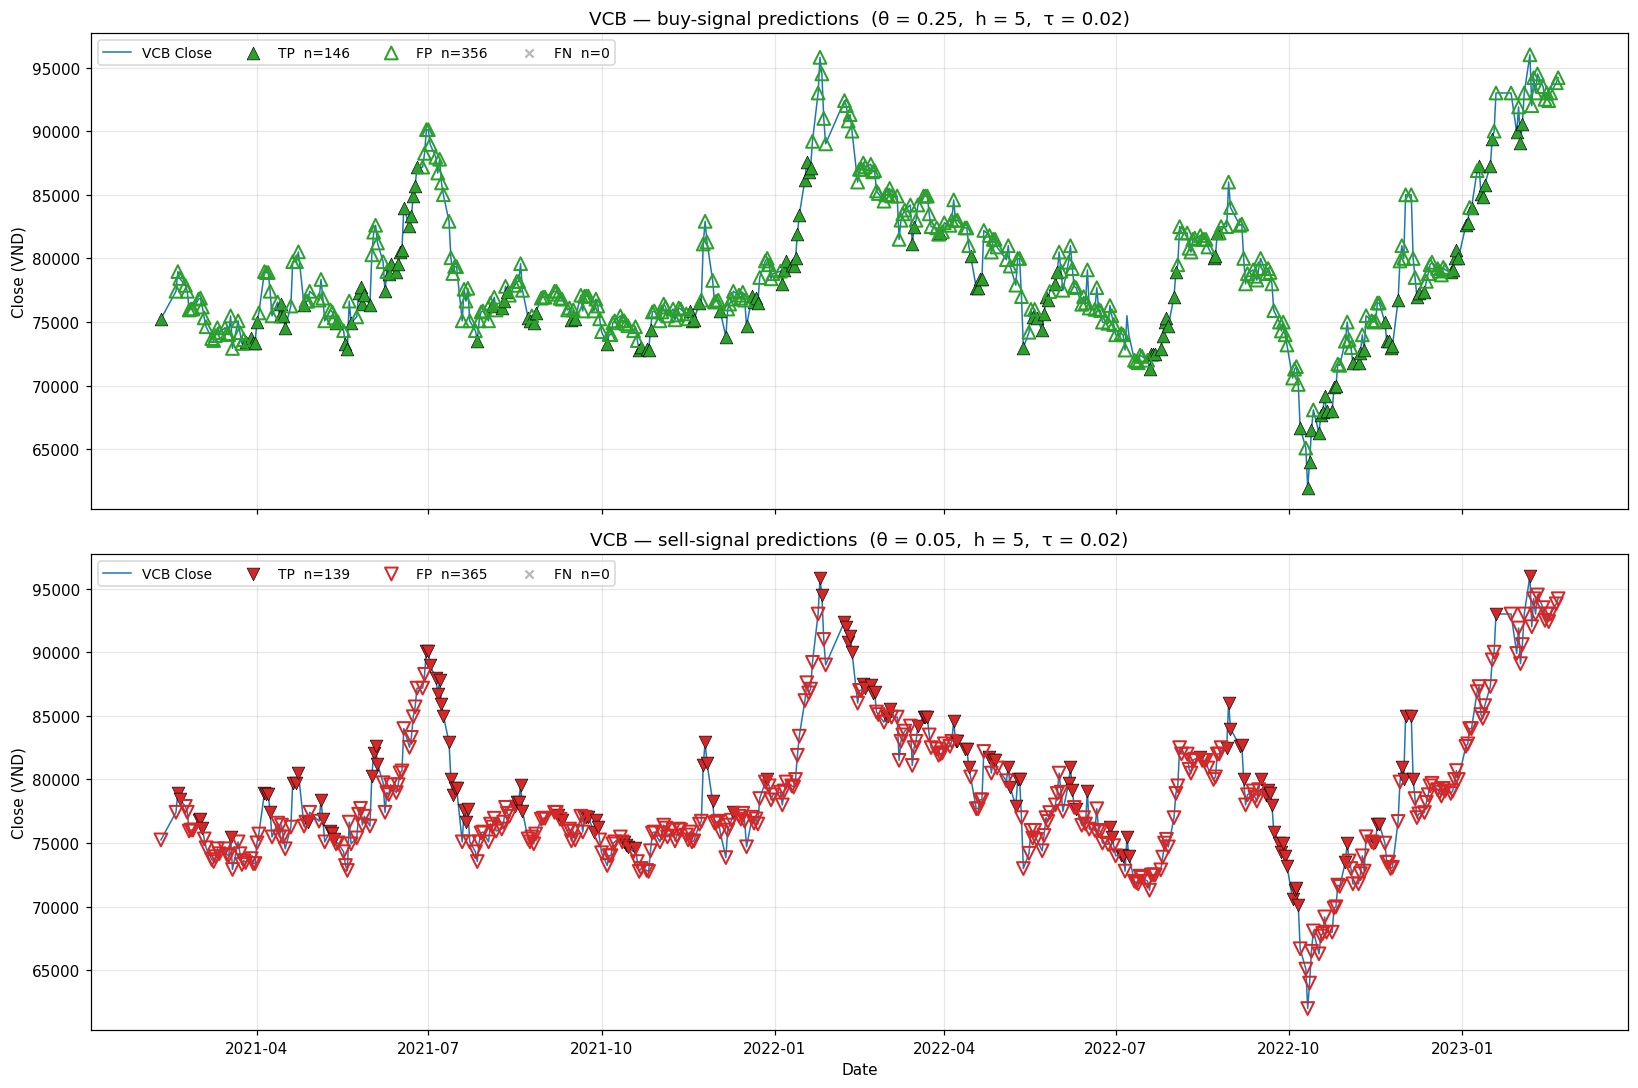

In [70]:
# VCB — predicted buy/sell signals overlaid on the test-set Close line.
# TP/FP/FN are computed against the actual realised future return (already encoded in test.y).

window_size = 30
horizon = SIGNAL_HORIZON

r_buy  = results_vn_buy['VCB']
r_sell = results_vn_sell['VCB']

# Predictions at the val-tuned θ
_, _, y_pred_buy,  _ = evaluate_test_clf(r_buy['model'],  r_buy['test'],  decision_threshold=r_buy['threshold'])
_, _, y_pred_sell, _ = evaluate_test_clf(r_sell['model'], r_sell['test'], decision_threshold=r_sell['threshold'])
y_true_buy  = r_buy['test'].y.astype(np.int8)
y_true_sell = r_sell['test'].y.astype(np.int8)

# Align windows to dates: window i in the test set has its decision day at feat_vcb index
#   test_start_idx + i + window_size - 1
# (the last day of the input window, i.e. when the trade would be entered).
test_start_idx = r_buy['train'].X.shape[0] + r_buy['val'].X.shape[0]
N_test = r_buy['test'].X.shape[0]
base = test_start_idx + window_size - 1
decision_dates = feat_vcb['Date'].iloc[base : base + N_test].reset_index(drop=True)
close_test     = feat_vcb['Close'].iloc[base : base + N_test].reset_index(drop=True)

def panel(ax, direction, y_pred, y_true, marker, color, title):
    ax.plot(decision_dates, close_test, color='tab:blue', linewidth=1.0, label='VCB Close', zorder=2)
    tp = (y_pred == 1) & (y_true == 1)
    fp = (y_pred == 1) & (y_true == 0)
    fn = (y_pred == 0) & (y_true == 1)
    ax.scatter(decision_dates[tp], close_test[tp], marker=marker, s=70, color=color,
               edgecolor='black', linewidth=0.4, label=f'TP  n={int(tp.sum())}', zorder=5)
    ax.scatter(decision_dates[fp], close_test[fp], marker=marker, s=70, facecolor='none',
               edgecolor=color, linewidth=1.3, label=f'FP  n={int(fp.sum())}', zorder=5)
    ax.scatter(decision_dates[fn], close_test[fn], marker='x', s=28, color='grey', alpha=0.55,
               label=f'FN  n={int(fn.sum())}', zorder=4)
    ax.set_title(title)
    ax.set_ylabel('Close (VND)')
    ax.legend(loc='upper left', ncol=4, fontsize=9)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), dpi=110, sharex=True)

panel(axes[0], 'buy',  y_pred_buy,  y_true_buy,  marker='^', color='tab:green',
      title=f"VCB — buy-signal predictions  (θ = {r_buy['threshold']:.2f},  h = {horizon},  τ = {SIGNAL_THRESHOLD:.2f})")
panel(axes[1], 'sell', y_pred_sell, y_true_sell, marker='v', color='tab:red',
      title=f"VCB — sell-signal predictions  (θ = {r_sell['threshold']:.2f},  h = {horizon},  τ = {SIGNAL_THRESHOLD:.2f})")
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


# TASK 4 — Vietnam portfolio composition & risk management

Task 4 is **not a new model** — it stitches together the heads we already trained.

| Subtask | Output we re-use | What we add |
|---|---|---|
| 4.1 Profitability | Task 2.3 multistep LSTM (k=7), take step h=5 → `E[return]_t` per ticker | Cross-sectional ranking on test |
| 4.2 Risk | Task 3.2 sell classifier → `P(sell)_t`; raw Close → 20-day rolling realised vol | Blended z-score risk per (date, ticker) |
| 4.3 Composition | Combined score `s = E[return] − λ·risk` | Cap-bounded weights, walk-forward backtest, two investor profiles |

No new training. The deep-learning core is in 2.3 and 3.2 — Task 4 is the allocation/backtest layer on top.

All weights are decided **using only information available at the decision day**:
forecasts come from models trained on Train only (best epoch by val_loss), and rolling vol is trailing.
The realised h-day return is used only for portfolio NAV evaluation.


## 4.1 Profitable stock selection

**Score.** For each ticker `t` and decision day `d` in the test window,
`E[return]_t,d = pred_close[d+5] / close[d] − 1` where `pred_close[d+5]` is the
5ᵗʰ step of the Task 2.3 multistep model trained on `(t, k=7)`. We picked the
k=7 model and step 5 (rather than re-training a dedicated h=5 head) because:

1. The model is already validated for k ∈ {3,7} via Task 2.3 per-step RMSE.
2. Step 5 lies *inside* the training horizon — no extrapolation past what the loss optimised.
3. Reusing the trained model keeps the DL stack identical to Task 2 and avoids
   another round of hyper-parameter justification.

**Aggregation.** We summarise each ticker by:

- `mean(E[return])` over the test window — naive "would I buy this on average?"
- `mean(realized_h_return)` — ground-truth average for sanity comparison
- **Hit rate** = `mean(sign(E[return]) == sign(realized_h_return))` — directional accuracy
- **Spearman rank-correlation** between `E[return]` and `realized_h_return` — does the model rank tickers right?

The ranking columns are what we lean on in 4.3; the levels are reported only for context.


In [71]:
# Task 4 helpers — portfolio scoring & backtest. No new training; we reuse the
# Task 2.3 multistep LSTMs and the Task 3.2 sell classifiers per Vietnam ticker.

from scipy.stats import spearmanr

PORTFOLIO_HORIZON     = 5      # rebalance / forecast horizon (matches Task 3)
VOL_WINDOW            = 20     # trading days for trailing realised volatility
PRUDENT_LAMBDA        = 2.0    # risk penalty, prudent investor (high)
AGGRESSIVE_LAMBDA     = 0.5    # risk penalty, aggressive investor (low)
PRUDENT_WEIGHT_CAP    = 0.25   # max single-name weight, prudent
AGGRESSIVE_WEIGHT_CAP = 0.50   # max single-name weight, aggressive
PRUDENT_EXCLUDE_TOP_K = 1      # drop the K riskiest names from prudent only
PORTFOLIO_TRADING_DAYS = 252


def predict_h_step_close(model, test_split, h):
    """Return the h-step-ahead predicted Close (denormalised, 1-D) from a Task 2.3 multistep model."""
    y_norm = model.predict(test_split.X, verbose=0)
    y_real = denormalize_label_multistep(y_norm, test_split.label_min, test_split.label_max)
    return y_real[:, h - 1]


def ticker_test_frame(ticker, h=PORTFOLIO_HORIZON):
    """Per-decision-day DataFrame over the test period.

    Columns: Date, Close, e_return, realized_h_return, rolling_vol, p_sell.
    All quantities are computed without look-ahead w.r.t. the decision day.
    """
    feat = add_technical_features(VN_RAW_FRAMES[ticker]).dropna().reset_index(drop=True)
    n_feat = len(feat)
    window_size = 30

    # k-day forecaster (Task 2.3 with k=7)
    r_kday = results_vn_kday[(ticker, 7)]
    te_kday = r_kday['test']
    n_kday_total = n_feat - window_size - 7 + 1
    n_kday_test  = te_kday.X.shape[0]
    kday_start = n_kday_total - n_kday_test
    feat_rows_k = kday_start + np.arange(n_kday_test) + window_size - 1   # decision-day row

    pred_close_h    = predict_h_step_close(r_kday['model'], te_kday, h)
    close_now       = feat['Close'].iloc[feat_rows_k].values
    close_future    = feat['Close'].iloc[feat_rows_k + h].values
    e_return        = pred_close_h / close_now - 1.0
    realized_h_return = close_future / close_now - 1.0

    # Sell-signal head (Task 3.2)
    r_sell = results_vn_sell[ticker]
    te_sell = r_sell['test']
    n_clf_total = n_feat - window_size - SIGNAL_HORIZON + 1
    n_clf_test  = te_sell.X.shape[0]
    clf_start   = n_clf_total - n_clf_test
    feat_rows_c = clf_start + np.arange(n_clf_test) + window_size - 1
    p_sell = r_sell['model'].predict(te_sell.X, verbose=0).ravel()

    # Trailing rolling vol of daily returns (computed on the full series; sliced per decision day)
    returns_full = feat['Close'].pct_change()
    vol_full     = returns_full.rolling(VOL_WINDOW).std()

    df_k = pd.DataFrame({
        'Date':              feat['Date'].iloc[feat_rows_k].values,
        'Close':             close_now,
        'e_return':          e_return,
        'realized_h_return': realized_h_return,
        'rolling_vol':       vol_full.iloc[feat_rows_k].values,
    })
    df_c = pd.DataFrame({
        'Date':   feat['Date'].iloc[feat_rows_c].values,
        'p_sell': p_sell,
    })
    return df_k.merge(df_c, on='Date', how='inner').sort_values('Date').reset_index(drop=True)


def build_test_panel():
    """Return {ticker -> per-decision-day DataFrame} for every Vietnam ticker."""
    return {t: ticker_test_frame(t) for t in VN_TICKERS}


def _wide(panel, col):
    """Stack one column across tickers into a wide DataFrame indexed by Date."""
    return pd.concat(
        [panel[t].set_index('Date')[[col]].rename(columns={col: t}) for t in panel],
        axis=1, join='outer',
    ).sort_index()


def _zrows(wide_df):
    sd = wide_df.std(axis=1, ddof=0).replace(0, np.nan)
    return wide_df.sub(wide_df.mean(axis=1), axis=0).div(sd, axis=0)


def compute_risk_panel(panel):
    """Cross-sectional risk in [0,1] per (date, ticker): row-min-max of (0.5·z(vol)+0.5·z(P(sell)))."""
    raw = 0.5 * _zrows(_wide(panel, 'rolling_vol')) + 0.5 * _zrows(_wide(panel, 'p_sell'))
    lo, hi = raw.min(axis=1), raw.max(axis=1)
    rng = (hi - lo).replace(0, np.nan)
    return raw.sub(lo, axis=0).div(rng, axis=0).fillna(0.5)


def compute_score(e_return_wide, risk_wide, lam):
    """Per-day, per-ticker score: E[return] - lambda * risk. Inputs and output share index/columns."""
    return e_return_wide.sub(lam * risk_wide.reindex_like(e_return_wide), fill_value=0.0)


def _row_weights(score_row, exclude_set, weight_cap):
    """Water-filling weights: scores → proportional weights, names that would exceed `weight_cap`
    get capped, leftover mass redistributes across the rest. Always sums to 1 if cap*n_active ≥ 1."""
    names  = list(score_row.index)
    active = np.array([t not in exclude_set for t in names])
    raw    = np.maximum(np.nan_to_num(score_row.values, nan=0.0), 0.0) * active
    if raw.sum() == 0:                          # no positive score → equal-weight active
        raw = active.astype(float)
    if active.sum() == 0:
        return pd.Series(np.zeros(len(names)), index=names)
    if active.sum() * weight_cap < 1.0 - 1e-9:  # cap too tight → all active at cap, sum < 1
        return pd.Series(active.astype(float) * weight_cap, index=names)

    capped = np.zeros_like(active)
    while True:
        free  = active & ~capped
        rem   = 1.0 - capped.sum() * weight_cap
        f_sum = raw[free].sum()
        if f_sum == 0:                          # remaining free have zero score → split equally
            w = capped.astype(float) * weight_cap
            n_free = int(free.sum())
            if n_free:
                w[free] = rem / n_free
            return pd.Series(w, index=names)
        prop = raw[free] / f_sum * rem
        if (prop > weight_cap + 1e-12).any():
            new_cap = np.zeros_like(active)
            new_cap[free] = (prop > weight_cap + 1e-12)
            capped = capped | new_cap
            continue
        w = capped.astype(float) * weight_cap
        w[free] = prop
        return pd.Series(w, index=names)


def build_weights(score_wide, risk_wide, weight_cap, exclude_top_k):
    """DataFrame[decision_date x ticker] of portfolio weights."""
    rows = []
    for date, srow in score_wide.iterrows():
        if exclude_top_k > 0 and date in risk_wide.index:
            excl = set(risk_wide.loc[date].nlargest(exclude_top_k).index)
        else:
            excl = set()
        rows.append(_row_weights(srow, excl, weight_cap))
    return pd.DataFrame(rows, index=score_wide.index).fillna(0.0)


def equal_weights_like(score_wide):
    """Equal-weight benchmark on the same calendar."""
    n = score_wide.shape[1]
    return pd.DataFrame(1.0 / n, index=score_wide.index, columns=score_wide.columns)


def daily_returns_calendar(panel):
    """Wide DataFrame[date x ticker] of close-to-close daily returns, covering the test span."""
    series = []
    for t in VN_TICKERS:
        feat = add_technical_features(VN_RAW_FRAMES[t]).dropna().reset_index(drop=True)
        s = pd.Series(feat['Close'].pct_change().values, index=pd.to_datetime(feat['Date'].values), name=t)
        series.append(s)
    return pd.concat(series, axis=1, join='outer').sort_index().fillna(0.0)


def backtest(weights, daily_returns, rebalance_every=PORTFOLIO_HORIZON):
    """Walk-forward backtest. Rebalance every `rebalance_every` decision days; keep weights fixed in between.

    Returns (nav, port_daily, active_weights) — NAV starts at 1.0 on the first rebalance day.
    """
    w_idx = pd.to_datetime(weights.index)
    rebal = weights.copy()
    rebal.index = w_idx
    rebal = rebal.iloc[::rebalance_every]
    start, end = rebal.index.min(), w_idx.max()

    dr_idx = daily_returns.index[(daily_returns.index >= start) & (daily_returns.index <= end)]
    if len(dr_idx) == 0:
        return pd.Series(dtype=float), pd.Series(dtype=float), pd.DataFrame()

    active = rebal.reindex(dr_idx, method='ffill').fillna(0.0)
    dr = daily_returns.loc[dr_idx, weights.columns].fillna(0.0)
    port_daily = (active * dr).sum(axis=1)
    nav = (1.0 + port_daily).cumprod()
    return nav, port_daily, active


def portfolio_metrics(nav, port_daily, trading_days=PORTFOLIO_TRADING_DAYS):
    """Annualised return, annualised Sharpe (rf=0), max drawdown."""
    nav_v = nav.values
    n_years = max(len(nav_v) / trading_days, 1e-9)
    total_ret = nav_v[-1] / nav_v[0] - 1.0 if len(nav_v) else 0.0
    ann_ret   = (1.0 + total_ret) ** (1.0 / n_years) - 1.0
    sd        = port_daily.std(ddof=0)
    sharpe    = float(np.sqrt(trading_days) * port_daily.mean() / sd) if sd > 0 else 0.0
    peak      = np.maximum.accumulate(nav_v)
    mdd       = float(((nav_v - peak) / peak).min()) if len(nav_v) else 0.0
    return {'Annualised Return': float(ann_ret), 'Sharpe': sharpe, 'Max Drawdown': mdd}


In [72]:
# Build the test panel once; reuse across 4.1 / 4.2 / 4.3.
test_panel = build_test_panel()

print(f"Task 4.1 — profitable stock selection  (h={PORTFOLIO_HORIZON} trading days)\n")
hdr = f"{'ticker':>6}  {'N_test':>7}  {'mean E[ret]':>11}  {'mean real':>10}  {'hit rate':>9}  {'rank ρ':>7}"
print(hdr); print('-' * len(hdr))

rows = []
for t in VN_TICKERS:
    df = test_panel[t]
    e, r = df['e_return'].values, df['realized_h_return'].values
    hit = float((np.sign(e) == np.sign(r)).mean())
    rho, _ = spearmanr(e, r)
    rows.append((t, len(df), float(e.mean()), float(r.mean()), hit, float(rho)))
    print(f"{t:>6}  {len(df):>7d}  {e.mean()*100:>10.2f}%  {r.mean()*100:>9.2f}%  "
          f"{hit*100:>8.1f}%  {rho:>7.3f}")

# Rank tickers by mean predicted h-day return — this is the profitability ranking 4.3 will lean on.
profit_rank = sorted(rows, key=lambda r: -r[2])
print(f"\nProfit ranking (by mean predicted h-day return):")
for i, (t, _, e, *_rest) in enumerate(profit_rank, 1):
    print(f"  {i}. {t:>4s}  {e*100:>+5.2f}%")


Task 4.1 — profitable stock selection  (h=5 trading days)

ticker   N_test  mean E[ret]   mean real   hit rate   rank ρ
------------------------------------------------------------
   VCB      502        0.51%       0.26%      53.0%    0.044
   HPG      562       -0.21%       0.30%      45.6%   -0.105
   FPT      596        0.32%       0.79%      56.2%    0.069
   VNM      630        0.27%      -0.04%      47.9%   -0.044
   MSN      489       -0.16%       0.40%      45.2%   -0.033
   MWG      314        1.51%      -0.55%      43.9%   -0.127

Profit ranking (by mean predicted h-day return):
  1.  MWG  +1.51%
  2.  VCB  +0.51%
  3.  FPT  +0.32%
  4.  VNM  +0.27%
  5.  MSN  -0.16%
  6.  HPG  -0.21%


## 4.2 Risk management

**Risk score.** For each `(date, ticker)` we combine two complementary signals:

- **Trailing realised volatility** — 20-day rolling std of daily `Close` returns.
  Classical risk view: how much has this stock been moving recently?
- **P(sell)** from the Task 3.2 LSTM — a *learned* bearish-regime probability.
  Captures patterns the rolling vol won't (e.g. small std but a downtrend).

We `z`-normalise each signal across **tickers** on each day (so risk is *relative* — at
least one name is the safest and one the riskiest on every day), average the two
z-scores, then min-max to `[0, 1]` per day. The result is interpretable: a ticker
with `risk=1.0` was the riskiest in the panel on that day; `risk=0.0` the safest.

This satisfies "identify risky companies to exclude": the **top-K** by risk on any
given day are flagged. In 4.3, the prudent investor drops the single
riskiest name on every rebalance day (`K=1`); the aggressive investor keeps everyone
and lets the score penalty do the work.


In [73]:
# Cross-sectional risk panel: [0,1] per (date, ticker), high = riskier.
risk_wide = compute_risk_panel(test_panel)

print(f"Task 4.2 — risk scoring  (z-blend of 20-day vol + P(sell), min-max per day)\n")
hdr = f"{'ticker':>6}  {'mean vol':>9}  {'mean P(sell)':>12}  {'mean risk':>10}  {'#riskiest':>10}  {'%riskiest':>10}"
print(hdr); print('-' * len(hdr))

# Per-ticker means + how often each ticker is the top-1 riskiest on a given day.
riskiest_each_day = risk_wide.idxmax(axis=1)
n_days = risk_wide.shape[0]
for t in VN_TICKERS:
    mean_vol  = float(np.mean([
        test_panel[t]['rolling_vol'].dropna().mean()
    ]))
    mean_ps   = float(test_panel[t]['p_sell'].mean())
    mean_risk = float(risk_wide[t].mean())
    n_top     = int((riskiest_each_day == t).sum())
    print(f"{t:>6}  {mean_vol:>9.4f}  {mean_ps:>12.3f}  {mean_risk:>10.3f}  {n_top:>10d}  {n_top/n_days*100:>9.1f}%")

print(f"\nNote: 'mean risk' is min-max-scaled to [0,1] per day, so cross-ticker means")
print(f"still average to ~0.5. '#riskiest' counts days the ticker had the top risk score.")


Task 4.2 — risk scoring  (z-blend of 20-day vol + P(sell), min-max per day)

ticker   mean vol  mean P(sell)   mean risk   #riskiest   %riskiest
-------------------------------------------------------------------
   VCB     0.0176         0.268       0.403          51        8.1%
   HPG     0.0243         0.320       0.878         392       62.2%
   FPT     0.0172         0.243       0.311          29        4.6%
   VNM     0.0145         0.236       0.140          15        2.4%
   MSN     0.0247         0.290       0.715         141       22.4%
   MWG     0.0238         0.243       0.446           2        0.3%

Note: 'mean risk' is min-max-scaled to [0,1] per day, so cross-ticker means
still average to ~0.5. '#riskiest' counts days the ticker had the top risk score.


/tmp/ipykernel_23157/4076185268.py:81: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(
/tmp/ipykernel_23157/4076185268.py:81: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(


## 4.3 Portfolio composition — prudent vs aggressive investor

**Single combined score.** Per `(date, ticker)`:
`s = E[return] − λ · risk`. Negative scores are clipped to zero before normalising
so under-water names get zero weight rather than going short.

**Two profiles** (knobs differ on `λ`, the weight cap, and whether we hard-exclude the riskiest name):

| Profile     | `λ` | Weight cap | Exclude top-K riskiest |
|-------------|----:|-----------:|----------------------:|
| Prudent     | 2.0 | 25%        | 1                     |
| Aggressive  | 0.5 | 50%        | 0                     |

**Backtest.** Walk-forward on the test window. Rebalance every 5 trading days (= `h`);
between rebalances weights stay fixed. NAV uses raw daily close-to-close returns
on a common calendar. We report:

- **Annualised Return** — profitability
- **Sharpe** (rf=0) — risk-adjusted return
- **Max Drawdown** — worst peak-to-trough

Both portfolios are benchmarked against an equal-weight allocation over the same
universe and same rebalance schedule, so any difference comes from the scoring,
not the universe choice.


In [74]:
# Wide panels aligned across tickers, then build weights for each profile.
e_return_wide = _wide(test_panel, 'e_return').dropna(how='any')          # intersection of test dates
risk_wide_int = risk_wide.reindex(e_return_wide.index)                   # match the same calendar

scores_prudent    = compute_score(e_return_wide, risk_wide_int, PRUDENT_LAMBDA)
scores_aggressive = compute_score(e_return_wide, risk_wide_int, AGGRESSIVE_LAMBDA)

weights_prudent = build_weights(
    scores_prudent, risk_wide_int,
    weight_cap=PRUDENT_WEIGHT_CAP, exclude_top_k=PRUDENT_EXCLUDE_TOP_K,
)
weights_aggressive = build_weights(
    scores_aggressive, risk_wide_int,
    weight_cap=AGGRESSIVE_WEIGHT_CAP, exclude_top_k=0,
)
weights_equal = equal_weights_like(e_return_wide)

# Backtest all three on the same daily-return calendar.
dr_panel = daily_returns_calendar(test_panel)

nav_p, ret_p, _ = backtest(weights_prudent,    dr_panel)
nav_a, ret_a, _ = backtest(weights_aggressive, dr_panel)
nav_e, ret_e, _ = backtest(weights_equal,      dr_panel)

m_p = portfolio_metrics(nav_p, ret_p)
m_a = portfolio_metrics(nav_a, ret_a)
m_e = portfolio_metrics(nav_e, ret_e)

print(f"Task 4.3 — portfolio backtest  (test window: {nav_p.index.min().date()} → {nav_p.index.max().date()}, "
      f"{len(nav_p)} trading days)\n")
print(f"{'profile':<13}  {'Ann. Return':>12}  {'Sharpe':>8}  {'Max DD':>8}")
print('-' * 47)
for name, m in [('Prudent', m_p), ('Aggressive', m_a), ('Equal-weight', m_e)]:
    print(f"{name:<13}  {m['Annualised Return']*100:>11.2f}%  {m['Sharpe']:>8.3f}  {m['Max Drawdown']*100:>7.2f}%")

# Stash results for reference in document.md / Local variable.yml.
portfolio_results = {
    'prudent':    {'nav': nav_p, 'returns': ret_p, 'weights': weights_prudent,    'metrics': m_p},
    'aggressive': {'nav': nav_a, 'returns': ret_a, 'weights': weights_aggressive, 'metrics': m_a},
    'equal':      {'nav': nav_e, 'returns': ret_e, 'weights': weights_equal,      'metrics': m_e},
}


/tmp/ipykernel_23157/4076185268.py:81: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(


Task 4.3 — portfolio backtest  (test window: 2021-11-12 → 2023-02-17, 314 trading days)

profile         Ann. Return    Sharpe    Max DD
-----------------------------------------------
Prudent              -8.33%    -0.213   -24.76%
Aggressive           -9.83%    -0.288   -26.47%
Equal-weight        -12.95%    -0.391   -33.51%


/tmp/ipykernel_23157/4076185268.py:165: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(series, axis=1, join='outer').sort_index().fillna(0.0)


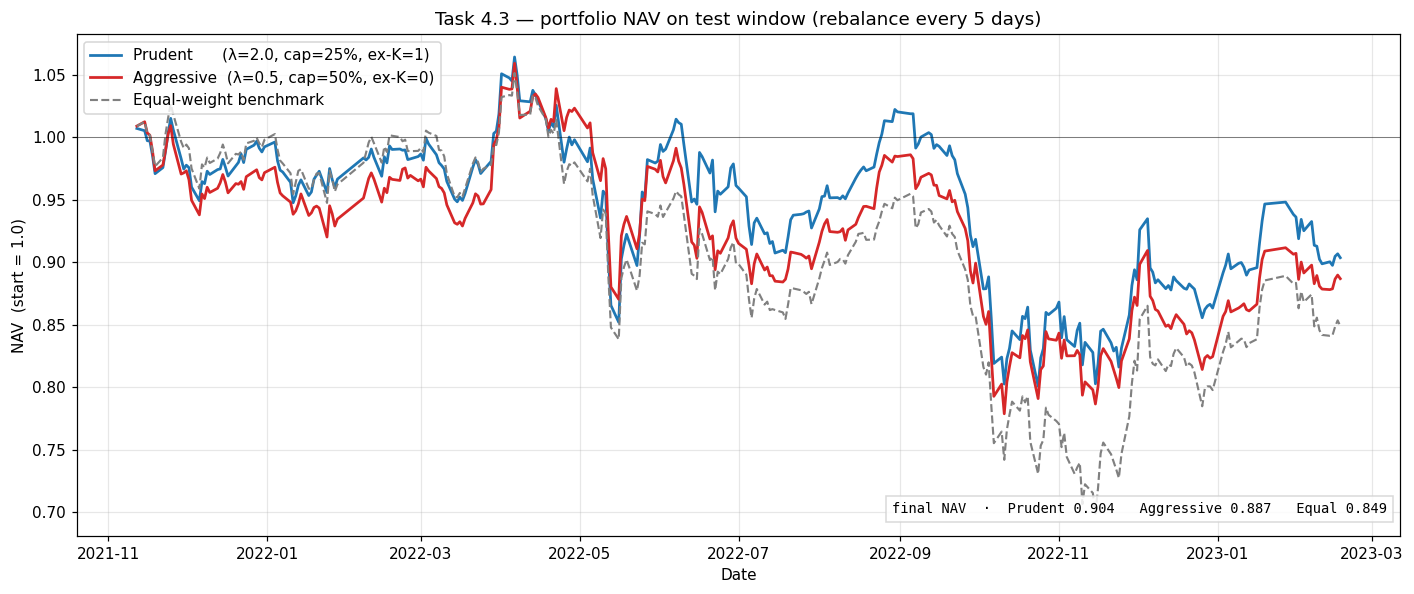

In [75]:
# NAV curves on the test window — single panel for clarity.
fig, ax = plt.subplots(figsize=(13, 5.5), dpi=110)

ax.plot(nav_p.index, nav_p.values, label=f"Prudent      (λ={PRUDENT_LAMBDA}, cap={PRUDENT_WEIGHT_CAP:.0%}, ex-K={PRUDENT_EXCLUDE_TOP_K})",
        color='tab:blue', linewidth=1.8)
ax.plot(nav_a.index, nav_a.values, label=f"Aggressive  (λ={AGGRESSIVE_LAMBDA}, cap={AGGRESSIVE_WEIGHT_CAP:.0%}, ex-K=0)",
        color='tab:red',  linewidth=1.8)
ax.plot(nav_e.index, nav_e.values, label='Equal-weight benchmark',
        color='grey', linewidth=1.4, linestyle='--')

ax.axhline(1.0, color='k', linewidth=0.6, alpha=0.5)
ax.set_xlabel('Date'); ax.set_ylabel('NAV  (start = 1.0)')
ax.set_title(f"Task 4.3 — portfolio NAV on test window "
             f"(rebalance every {PORTFOLIO_HORIZON} days)")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Final-value annotations (top-right inset)
yend = max(nav_p.iloc[-1], nav_a.iloc[-1], nav_e.iloc[-1])
ax.text(0.99, 0.04,
        f"final NAV  ·  Prudent {nav_p.iloc[-1]:.3f}   Aggressive {nav_a.iloc[-1]:.3f}   Equal {nav_e.iloc[-1]:.3f}",
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, family='monospace',
        bbox=dict(facecolor='white', edgecolor='lightgrey', alpha=0.85))

plt.tight_layout()
plt.show()
